**Group:** Kushagra Gulati-2423347, Udit Baid-2423384, Farhan Aziz-2423377, Soham Sahasrabudhe-2423363

# Car Purchase Amount Prediction Dataset

**Date:** 23rd February 2026

*Data Source: [Kaggle - Sales Prediction Dataset](https://www.kaggle.com/datasets/mohdshahnawazaadil/sales-prediction-dataset?select=car_purchasing.csv)*

**Description:** This project builds a multiple linear regression model to estimate car purchase amounts based on customer demographic and financial attributes.

## 1. Image

![Car Purchase](https://images.unsplash.com/photo-1558618666-fcd25c85cd64?ixlib=rb-4.0.3&auto=format&fit=crop&w=1000&q=80)

## 2. Description

### Research Questions
- What are the key demographic and financial factors that influence the amount customers spend on car purchases?
- How do age, annual salary, net worth, and credit card debt individually and collectively affect car purchase amounts?
- Can we predict car purchase amounts accurately using multiple linear regression based on customer profiles?

### Objective
The objective of this analysis is to build a predictive model using multiple linear regression to estimate car purchase amounts based on customer demographic and financial attributes. This will help automotive retailers understand customer behavior and optimize marketing strategies.

### Hypotheses
- **H1:** Net worth has a positive significant effect on car purchase amount.
- **H2:** Annual salary has a positive significant effect on car purchase amount.
- **H3:** Age has a significant effect on car purchase amount.
- **H4:** Credit card debt has a negative significant effect on car purchase amount.
- **H5:** Gender does not significantly affect car purchase amount.

## 3. Data

### Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

%matplotlib inline
print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


### Load Dataset

In [40]:
FILE_PATH = 'car_purchasing.csv'
df = pd.read_csv(FILE_PATH, encoding='latin-1')

# Normalize all column names to lowercase and strip whitespace
df.columns = df.columns.str.strip().str.lower()

print(f'✅ Dataset loaded — Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')

✅ Dataset loaded — Shape: 500 rows × 9 columns
Columns: ['customer name', 'customer e-mail', 'country', 'gender', 'age', 'annual salary', 'credit card debt', 'net worth', 'car purchase amount']


This code loads the car purchasing dataset from a CSV file. The dataset contains customer information including demographics and financial attributes that will be used to predict car purchase amounts. Column names are normalized to lowercase for consistency.

### EDA

In [41]:
print('=== First 5 Rows ===')
df.head()

=== First 5 Rows ===


,customer name,customer e-mail,country,gender,age,annual salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [42]:
print('=== Data Types & Non-Null Counts ===')
df.info()

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    object 
 1   customer e-mail      500 non-null    object 
 2   country              500 non-null    object 
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 35.3+ KB


In [43]:
print('=== Summary Statistics ===')
df.describe()

=== Summary Statistics ===


,gender,age,annual salary,credit card debt,net worth,car purchase amount
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.506000,46.241674,62127.239608,9607.645049,431475.713625,44209.799218
std,0.500465,7.978862,11703.378228,3489.187973,173536.756340,10773.178744
min,0.000000,20.000000,20000.000000,100.000000,20000.000000,9000.000000
25%,0.000000,40.949969,54391.977195,7397.515792,299824.195900,37629.896040
50%,1.000000,46.049901,62915.497035,9655.035568,426750.120650,43997.783390
75%,1.000000,51.612263,70117.862005,11798.867487,557324.478725,51254.709517
max,1.000000,70.000000,100000.000000,20000.000000,1000000.000000,80000.000000


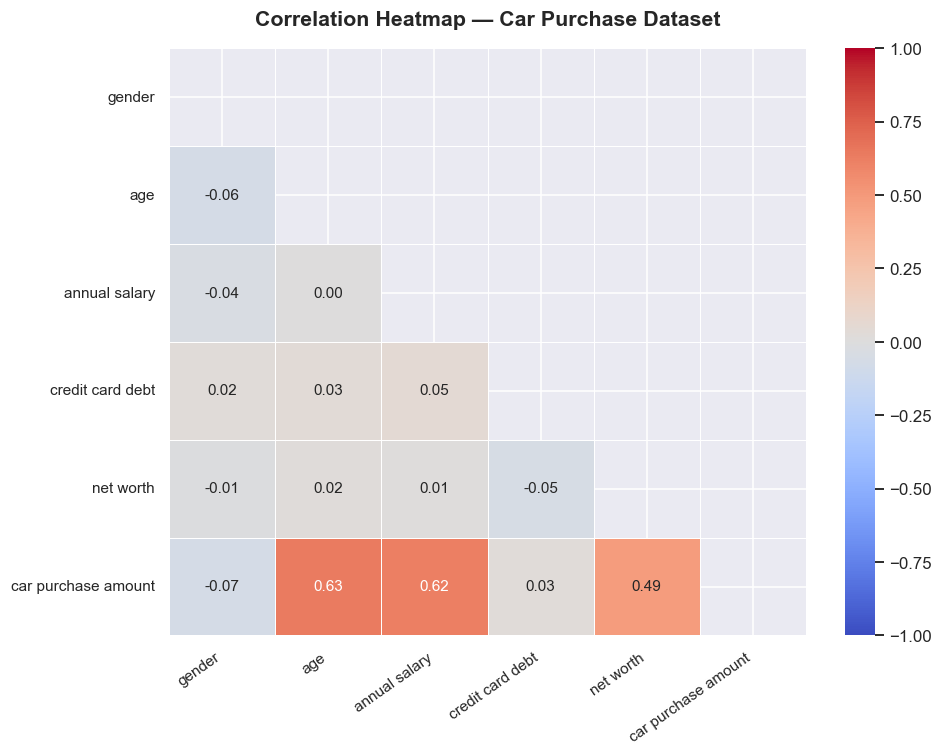


Correlation with Target (car purchase amount):
age                 0.632865
annual salary       0.617862
net worth           0.488580
credit card debt    0.028882
gender             -0.066408


In [44]:
# Correlation Heatmap
df_numeric = df.select_dtypes(include=[np.number])
corr_matrix = df_numeric.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
			center=0, linewidths=0.5, linecolor='white', annot_kws={'size': 10},
			vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Heatmap — Car Purchase Dataset', fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Target column is 'car purchase amount' (all lowercase after normalization)
TARGET = 'car purchase amount'
print('\nCorrelation with Target (car purchase amount):')
print(corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False).to_string())

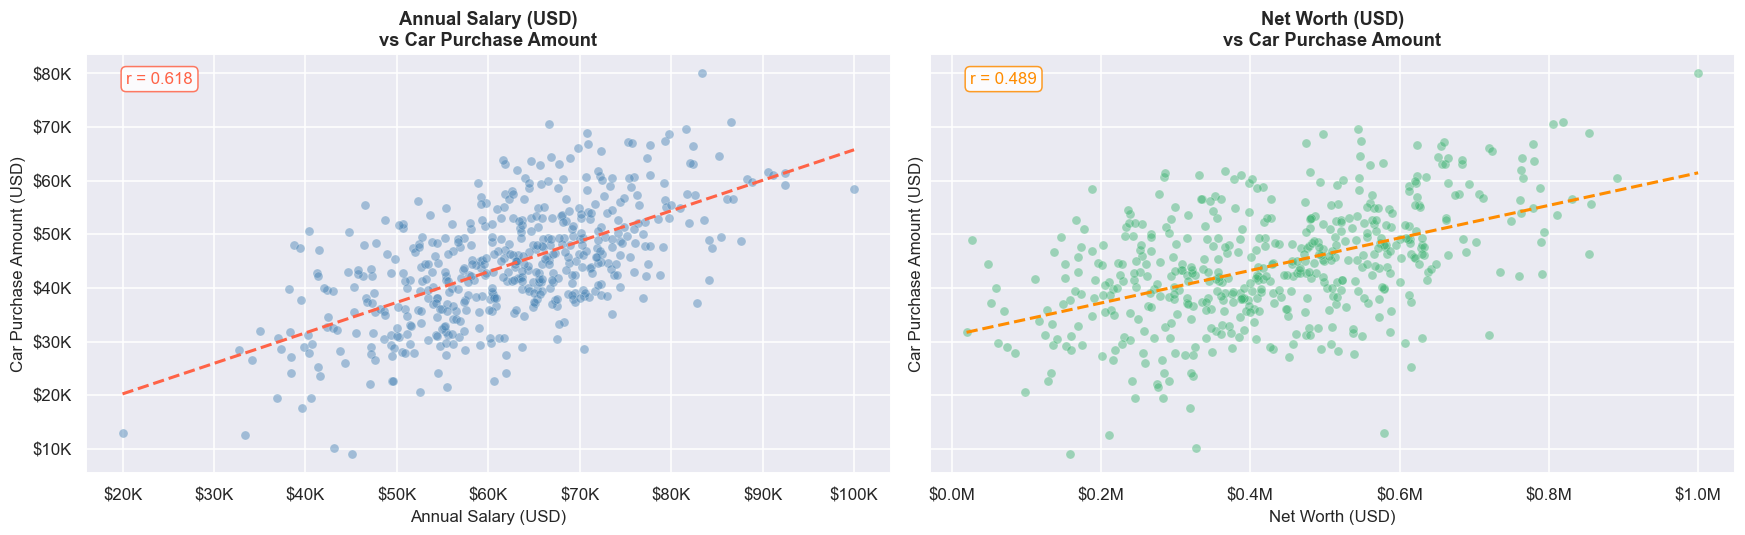

In [45]:
TARGET = 'car purchase amount'

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
features   = ['annual salary', 'net worth']
xlabels    = ['Annual Salary (USD)', 'Net Worth (USD)']
colors     = ['steelblue', 'mediumseagreen']
trend_cols = ['tomato', 'darkorange']
x_fmts     = [mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'),
			   mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')]

for ax, feat, xlabel, col, tc, xfmt in zip(axes, features, xlabels, colors, trend_cols, x_fmts):
	ax.scatter(df[feat], df[TARGET],
			   alpha=0.45, color=col, edgecolors='white', linewidths=0.3, s=35)
	z = np.polyfit(df[feat], df[TARGET], 1)
	xr = np.linspace(df[feat].min(), df[feat].max(), 300)
	ax.plot(xr, np.poly1d(z)(xr), color=tc, linewidth=2, linestyle='--')
	r = np.corrcoef(df[feat], df[TARGET])[0, 1]
	ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.93), xycoords='axes fraction', fontsize=11, color=tc,
				bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=tc, alpha=0.85))
	ax.set_xlabel(xlabel, fontsize=11)
	ax.set_ylabel('Car Purchase Amount (USD)', fontsize=11)
	ax.set_title(f'{xlabel}\nvs Car Purchase Amount', fontsize=12, fontweight='bold')
	ax.xaxis.set_major_formatter(xfmt)
	ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y/1e3:.0f}K'))

plt.tight_layout()
plt.show()

### 📊 Feature Distributions — Histograms & KDE

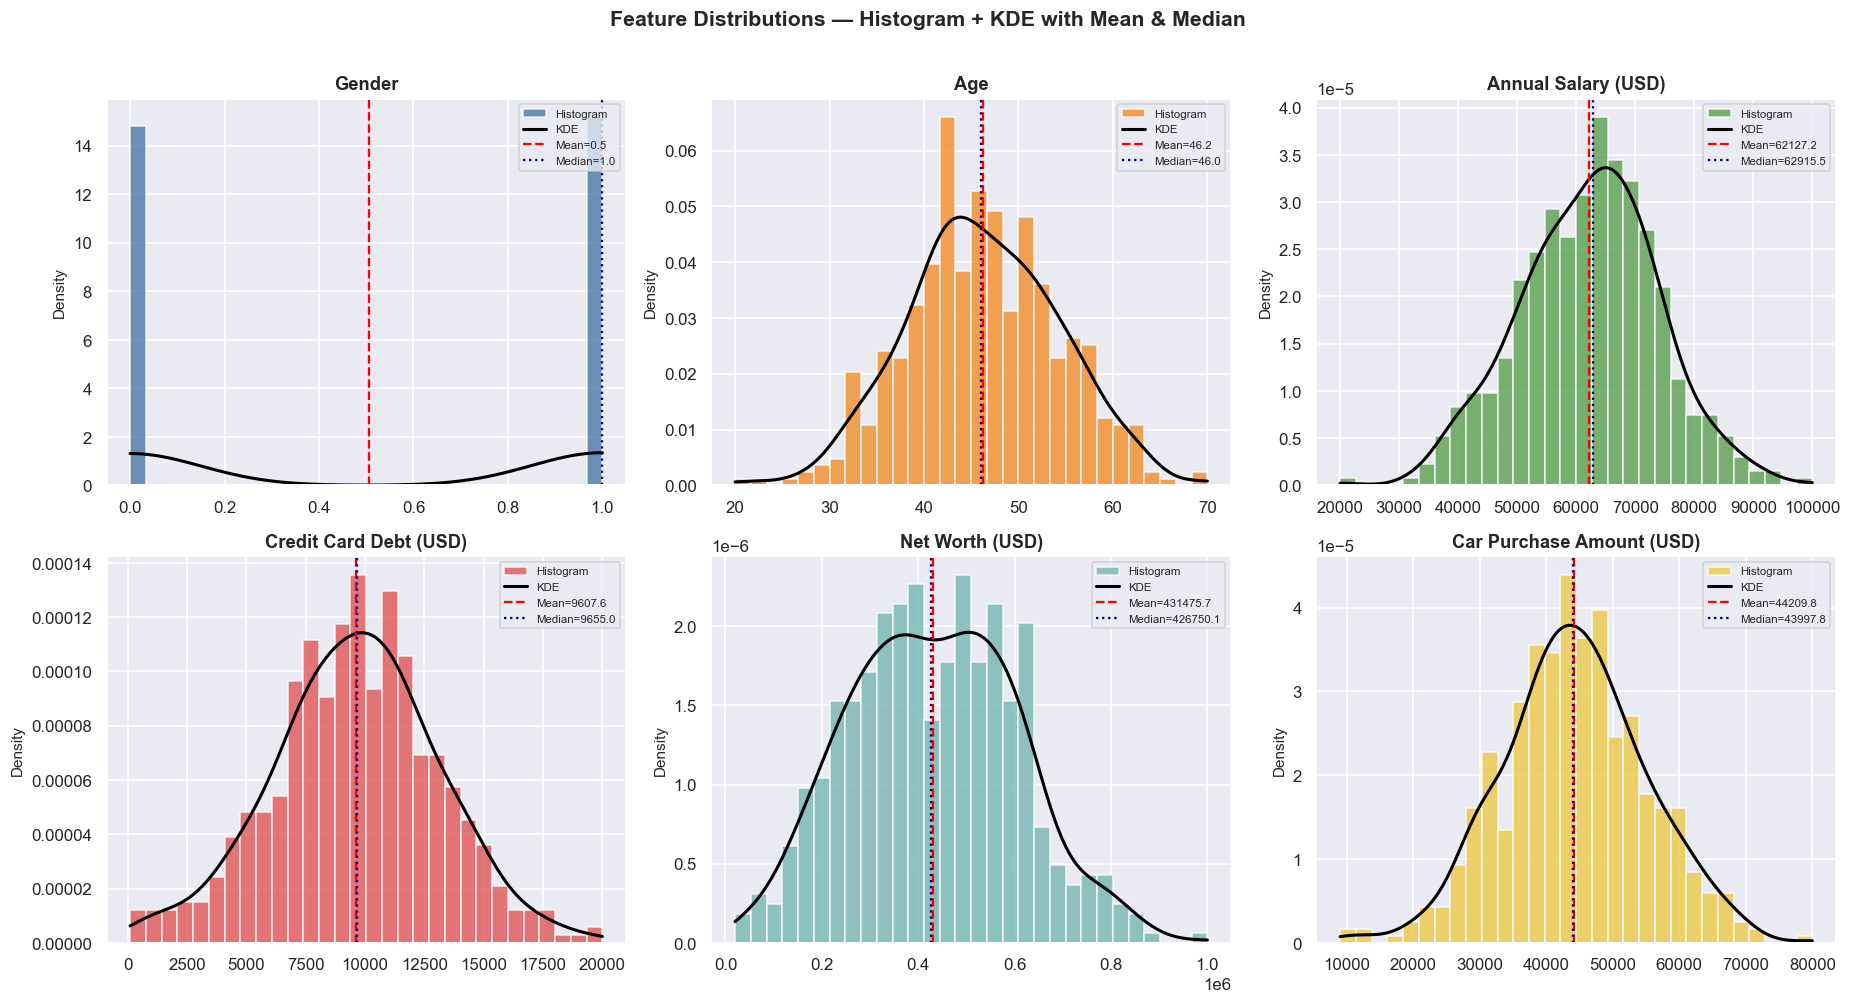

In [46]:
TARGET = 'car purchase amount'
features_plot = ['gender', 'age', 'annual salary', 'credit card debt', 'net worth', TARGET]
titles = ['Gender', 'Age', 'Annual Salary (USD)', 'Credit Card Debt (USD)', 'Net Worth (USD)', 'Car Purchase Amount (USD)']

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

palette = ['#4e79a7','#f28e2b','#59a14f','#e15759','#76b7b2','#edc948']

for ax, feat, title, col in zip(axes, features_plot, titles, palette):
	data = df[feat].dropna()
	ax.hist(data, bins=30, color=col, edgecolor='white', alpha=0.80, density=True, label='Histogram')
	from scipy.stats import gaussian_kde
	kde = gaussian_kde(data, bw_method=0.3)
	xs  = np.linspace(data.min(), data.max(), 300)
	ax.plot(xs, kde(xs), color='black', lw=2, label='KDE')
	ax.axvline(data.mean(),   color='red',    lw=1.5, linestyle='--', label=f'Mean={data.mean():.1f}')
	ax.axvline(data.median(), color='navy',   lw=1.5, linestyle=':',  label=f'Median={data.median():.1f}')
	ax.set_title(title, fontsize=12, fontweight='bold')
	ax.set_ylabel('Density', fontsize=10)
	ax.legend(fontsize=7.5, loc='upper right')

fig.suptitle('Feature Distributions — Histogram + KDE with Mean & Median',
			 fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 📦 Box Plots — Before vs After IQR Outlier Capping

In [47]:
df_clean = df.drop(columns=['customer name', 'customer e-mail', 'country'])

# Median imputation for missing values
for col in df_clean.columns[df_clean.isnull().any()]:
	df_clean[col].fillna(df_clean[col].median(), inplace=True)

# IQR Winsorization (outlier capping)
df_clean_no_outliers = df_clean.copy()
total_capped = 0
for col in df_clean_no_outliers.select_dtypes(include=[np.number]).columns:
	Q1, Q3 = df_clean_no_outliers[col].quantile([0.25, 0.75])
	IQR = Q3 - Q1
	lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
	n = ((df_clean_no_outliers[col] < lb) | (df_clean_no_outliers[col] > ub)).sum()
	df_clean_no_outliers[col] = df_clean_no_outliers[col].clip(lower=lb, upper=ub)
	total_capped += n

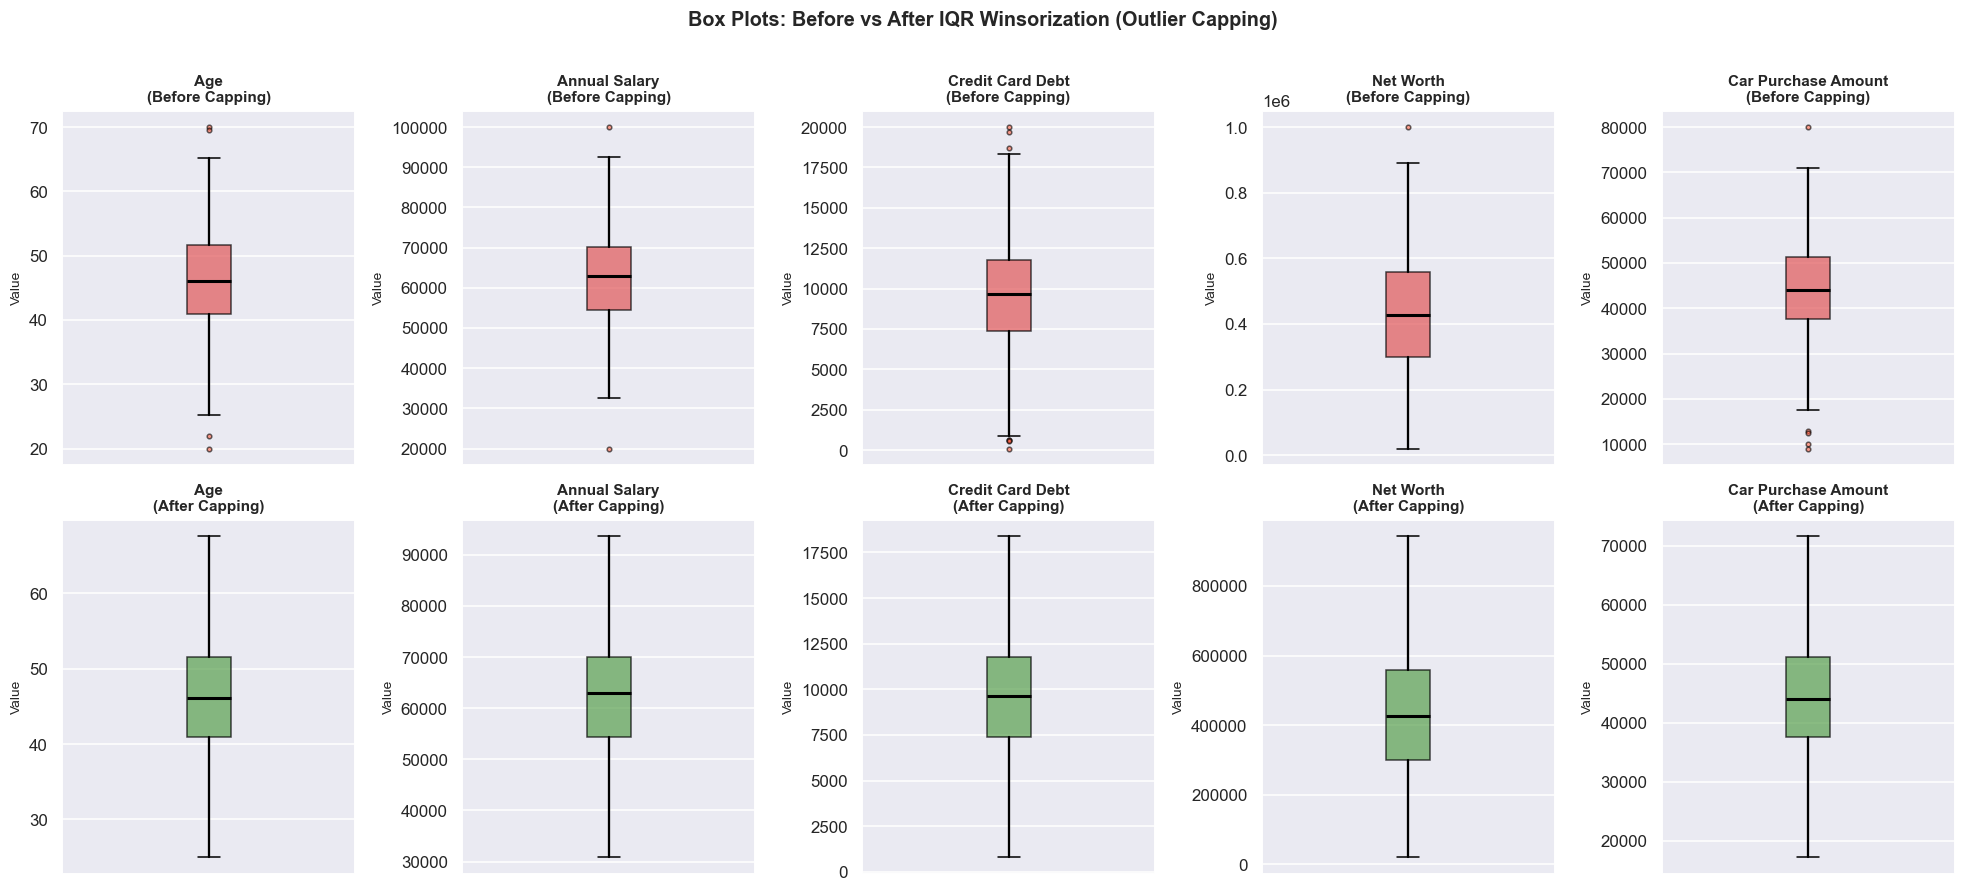

In [48]:
TARGET = 'car purchase amount'
num_cols = ['age', 'annual salary', 'credit card debt', 'net worth', TARGET]

# df_clean = before capping  |  df_clean_no_outliers = after capping
fig, axes = plt.subplots(2, len(num_cols), figsize=(18, 8))

for col_idx, col in enumerate(num_cols):
	for row_idx, (data, label, color) in enumerate([
		(df_clean[col],              'Before Capping', '#e15759'),
		(df_clean_no_outliers[col],  'After Capping',  '#59a14f')
	]):
		ax = axes[row_idx][col_idx]
		bp = ax.boxplot(data.dropna(), patch_artist=True, notch=False,
						medianprops=dict(color='black', lw=2),
						boxprops=dict(facecolor=color, alpha=0.70),
						whiskerprops=dict(lw=1.5),
						flierprops=dict(marker='o', markersize=3,
										markerfacecolor='tomato', alpha=0.6))
		ax.set_title(f'{col.title()}\n({label})', fontsize=10, fontweight='bold')
		ax.set_xticks([])
		ax.set_ylabel('Value', fontsize=9)

fig.suptitle('Box Plots: Before vs After IQR Winsorization (Outlier Capping)',
			 fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 🔗 Pair Plot — Feature Relationships with Target

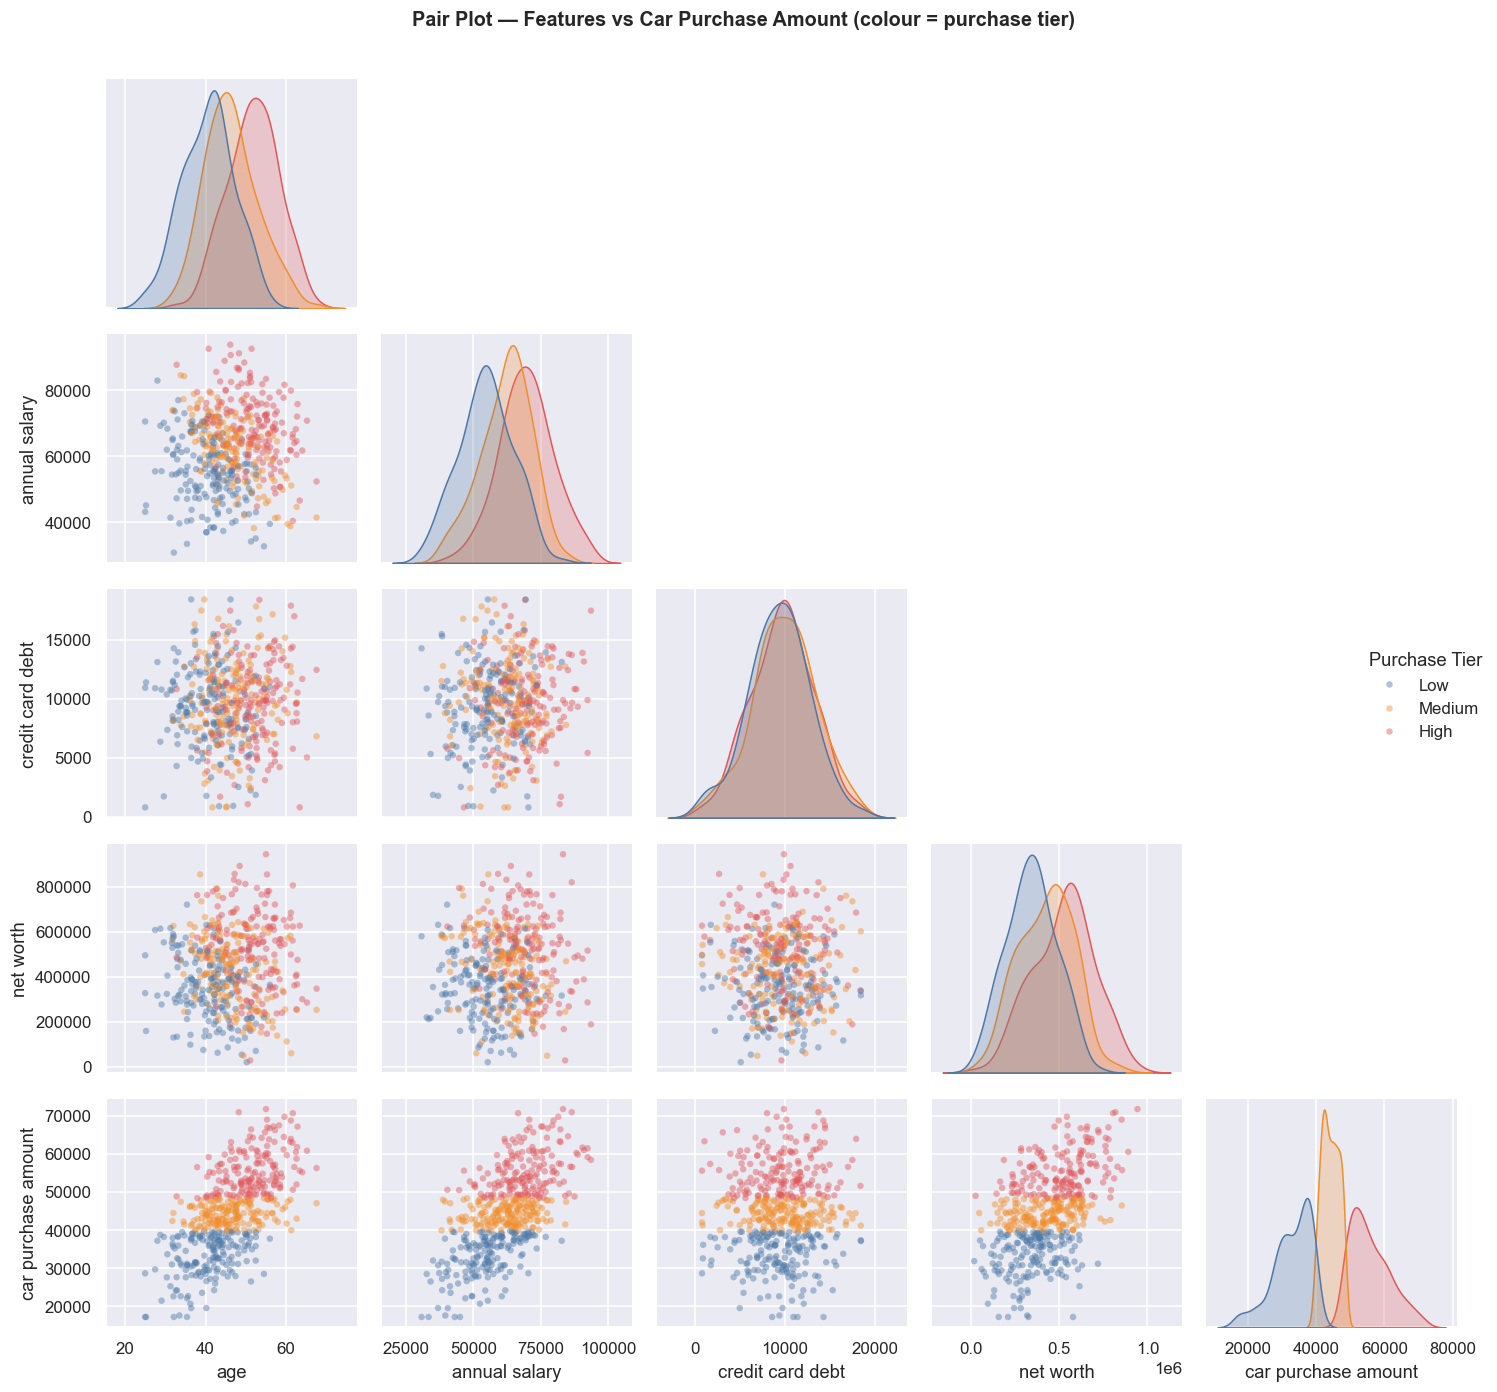

In [49]:
TARGET = 'car purchase amount'
pair_cols = ['age', 'annual salary', 'credit card debt', 'net worth', TARGET]

pair_df = df_clean_no_outliers[pair_cols].copy()
# Bin target for colour coding
pair_df['Purchase Tier'] = pd.qcut(
	pair_df[TARGET], q=3,
	labels=['Low', 'Medium', 'High']
)

g = sns.pairplot(
	pair_df, hue='Purchase Tier',
	vars=pair_cols,
	palette={'Low': '#4e79a7', 'Medium': '#f28e2b', 'High': '#e15759'},
	plot_kws=dict(alpha=0.45, edgecolor='none', s=18),
	diag_kind='kde',
	corner=True
)
g.figure.suptitle('Pair Plot — Features vs Car Purchase Amount (colour = purchase tier)',
				  fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 🎯 Target Variable Analysis — Car Purchase Amount

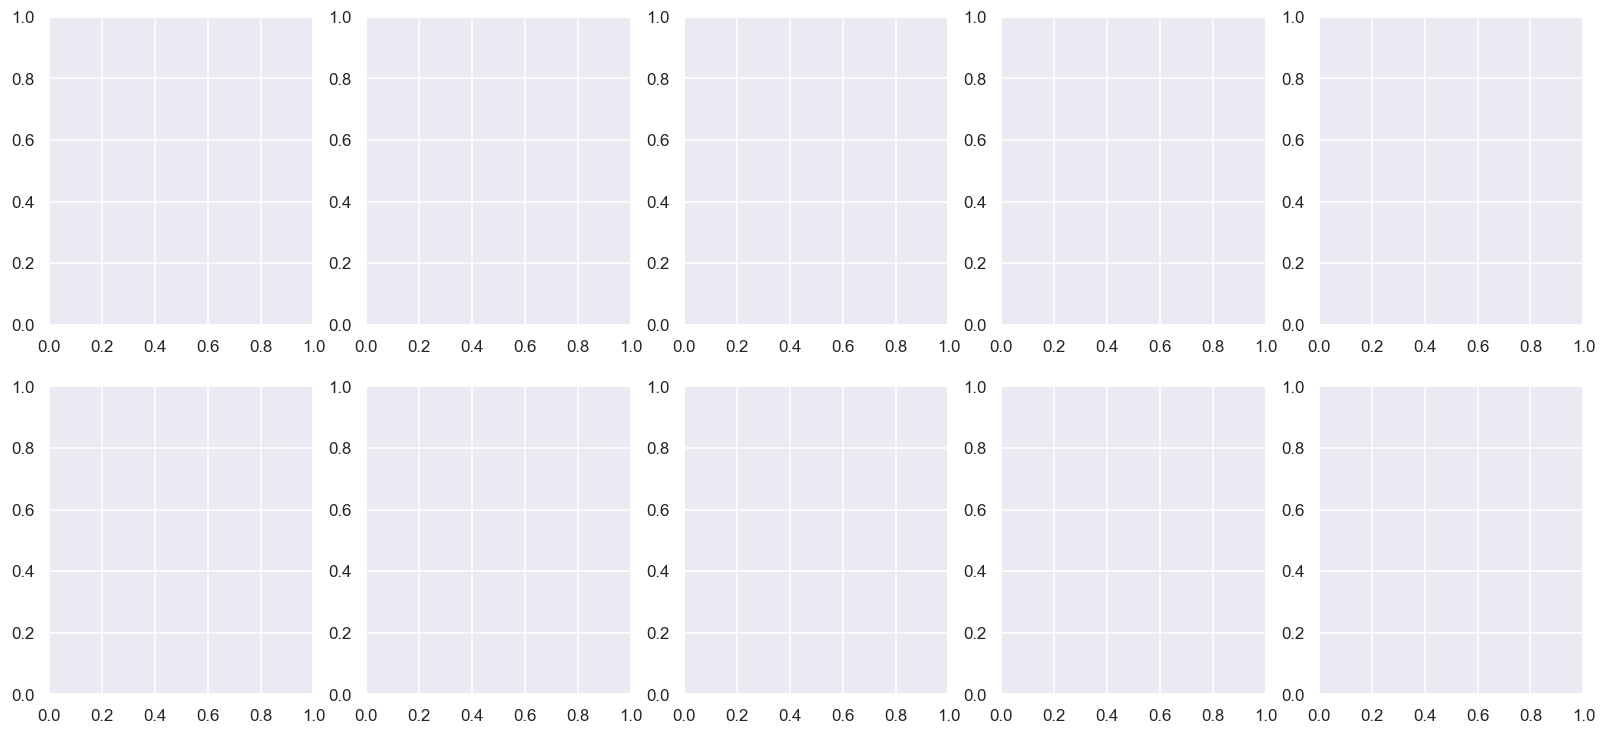

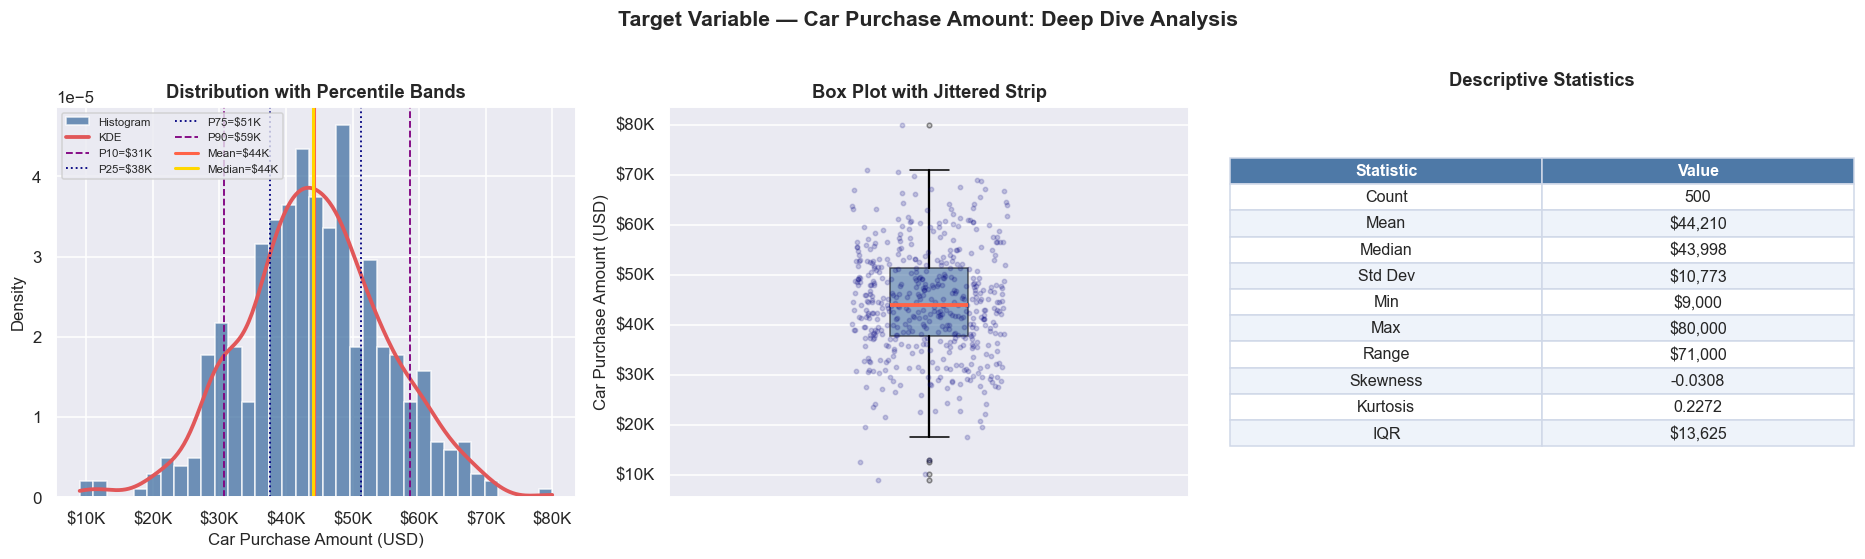

Skewness: -0.0308 — approx. symmetric
Kurtosis: 0.2272 — leptokurtic (heavy tails)


In [12]:
# scipy.stats already imported globally as `stats`

TARGET = 'car purchase amount'
target_data = df[TARGET].dropna()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Panel 1: Histogram + KDE with percentile bands ─────────────────────
axes[0].hist(target_data, bins=35, color='#4e79a7', edgecolor='white',
			 alpha=0.80, density=True, label='Histogram')
xs = np.linspace(target_data.min(), target_data.max(), 300)
kde = stats.gaussian_kde(target_data, bw_method=0.25)
axes[0].plot(xs, kde(xs), color='#e15759', lw=2.5, label='KDE')
for pct, col, ls in [(10,'purple','--'),(25,'navy',':'),(75,'navy',':'),(90,'purple','--')]:
	v = np.percentile(target_data, pct)
	axes[0].axvline(v, color=col, lw=1.2, linestyle=ls,
					label=f'P{pct}=${v/1e3:.0f}K')
axes[0].axvline(target_data.mean(),   color='tomato', lw=2, linestyle='-',
				label=f'Mean=${target_data.mean()/1e3:.0f}K')
axes[0].axvline(target_data.median(), color='gold',   lw=2, linestyle='-',
				label=f'Median=${target_data.median()/1e3:.0f}K')
axes[0].set_xlabel('Car Purchase Amount (USD)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Distribution with Percentile Bands', fontsize=12, fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0].legend(fontsize=7.5, ncol=2)

# ── Panel 2: Box plot with jittered strip ──────────────────────────────
axes[1].boxplot(target_data, patch_artist=True,
				boxprops=dict(facecolor='#4e79a7', alpha=0.6),
				medianprops=dict(color='tomato', lw=2.5),
				whiskerprops=dict(lw=1.5),
				flierprops=dict(marker='o', ms=3, alpha=0.4, markerfacecolor='grey'))
jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(target_data))
axes[1].scatter(1 + jitter, target_data, alpha=0.18, s=8, color='navy', zorder=2)
axes[1].set_ylabel('Car Purchase Amount (USD)', fontsize=11)
axes[1].set_title('Box Plot with Jittered Strip', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'${y/1e3:.0f}K'))
axes[1].set_xticks([])

# ── Panel 3: Descriptive stats table ──────────────────────────────────
axes[2].axis('off')
skew_val = target_data.skew()
kurt_val = target_data.kurtosis()
stats_data = [
	['Statistic', 'Value'],
	['Count',       f'{len(target_data):,}'],
	['Mean',        f'${target_data.mean():,.0f}'],
	['Median',      f'${target_data.median():,.0f}'],
	['Std Dev',     f'${target_data.std():,.0f}'],
	['Min',         f'${target_data.min():,.0f}'],
	['Max',         f'${target_data.max():,.0f}'],
	['Range',       f'${(target_data.max()-target_data.min()):,.0f}'],
	['Skewness',    f'{skew_val:.4f}'],
	['Kurtosis',    f'{kurt_val:.4f}'],
	['IQR',         f'${(target_data.quantile(.75)-target_data.quantile(.25)):,.0f}'],
]
tbl = axes[2].table(cellText=stats_data[1:], colLabels=stats_data[0],
					loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10.5)
tbl.scale(1.2, 1.55)
for (r,c), cell in tbl.get_celld().items():
	if r == 0:
		cell.set_facecolor('#4e79a7')
		cell.set_text_props(color='white', fontweight='bold')
	elif r % 2 == 0:
		cell.set_facecolor('#eef3fa')
	cell.set_edgecolor('#d0d8e8')
axes[2].set_title('Descriptive Statistics', fontsize=12, fontweight='bold', pad=14)

fig.suptitle('Target Variable — Car Purchase Amount: Deep Dive Analysis',
			 fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f'Skewness: {skew_val:.4f} — {"approx. symmetric" if abs(skew_val)<0.5 else ("moderately skewed" if abs(skew_val)<1 else "highly skewed")}')
print(f'Kurtosis: {kurt_val:.4f} — {"leptokurtic (heavy tails)" if kurt_val>0 else "platykurtic (light tails)"}')

### ⚥ Gender vs Car Purchase Amount

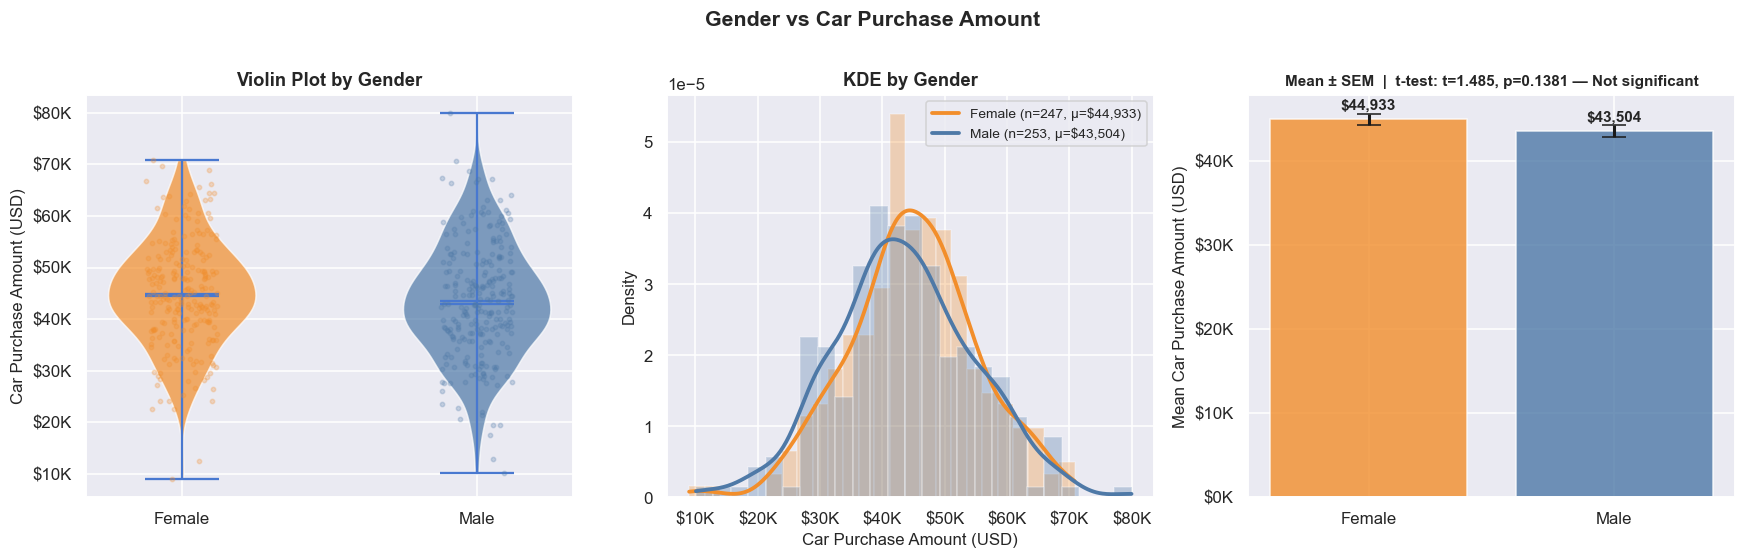

In [50]:
TARGET = 'car purchase amount'

df_gender = df.copy()
df_gender['Gender Label'] = df_gender['gender'].map({0:'Female', 1:'Male'})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Violin Plot ──────────────────────────────────────────────
genders = ['Female', 'Male']
vdata = [df_gender[df_gender['Gender Label']==g][TARGET].dropna() for g in genders]
parts = axes[0].violinplot(vdata, positions=[0,1], showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
	pc.set_facecolor(['#f28e2b','#4e79a7'][i])
	pc.set_alpha(0.7)
jitter = np.random.default_rng(0).uniform(-0.12, 0.12, len(df_gender))
for i, (g, col) in enumerate(zip(genders, ['#f28e2b','#4e79a7'])):
	mask = df_gender['Gender Label'] == g
	axes[0].scatter(i + jitter[mask.values], df_gender[mask][TARGET],
					alpha=0.25, s=8, color=col, zorder=2)
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(genders, fontsize=11)
axes[0].set_ylabel('Car Purchase Amount (USD)', fontsize=11)
axes[0].set_title('Violin Plot by Gender', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'${y/1e3:.0f}K'))

# ── Panel 2: KDE Overlay by gender ───────────────────────────────────
for g, col in zip(genders, ['#f28e2b','#4e79a7']):
	d = df_gender[df_gender['Gender Label']==g][TARGET].dropna()
	axes[1].hist(d, bins=25, density=True, alpha=0.3, color=col, edgecolor='white')
	xs = np.linspace(d.min(), d.max(), 300)
	axes[1].plot(xs, stats.gaussian_kde(d, bw_method=0.3)(xs),
				 color=col, lw=2.5, label=f'{g} (n={len(d)}, μ=${d.mean():,.0f})')
axes[1].set_xlabel('Car Purchase Amount (USD)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('KDE by Gender', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))

# ── Panel 3: Mean + CI ────────────────────────────────────────────────
means = [df_gender[df_gender['Gender Label']==g][TARGET].mean() for g in genders]
sems  = [stats.sem(df_gender[df_gender['Gender Label']==g][TARGET].dropna()) for g in genders]
bars  = axes[2].bar(genders, means, yerr=sems, capsize=8,
					color=['#f28e2b','#4e79a7'], edgecolor='white',
					alpha=0.80, error_kw=dict(lw=2))
for bar, val in zip(bars, means):
	axes[2].text(bar.get_x()+bar.get_width()/2, val + max(sems)*1.2,
				 f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# T-test
t_stat, t_p = stats.ttest_ind(
	df_gender[df_gender['Gender Label']=='Female'][TARGET].dropna(),
	df_gender[df_gender['Gender Label']=='Male'][TARGET].dropna()
)
sig_txt = f't={t_stat:.3f}, p={t_p:.4f} — {"Significant" if t_p<0.05 else "Not significant"}'
axes[2].set_title(f'Mean ± SEM  |  t-test: {sig_txt}', fontsize=10, fontweight='bold')
axes[2].set_ylabel('Mean Car Purchase Amount (USD)', fontsize=11)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'${y/1e3:.0f}K'))

fig.suptitle('Gender vs Car Purchase Amount',
			 fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 📅 Age Group vs Car Purchase Amount

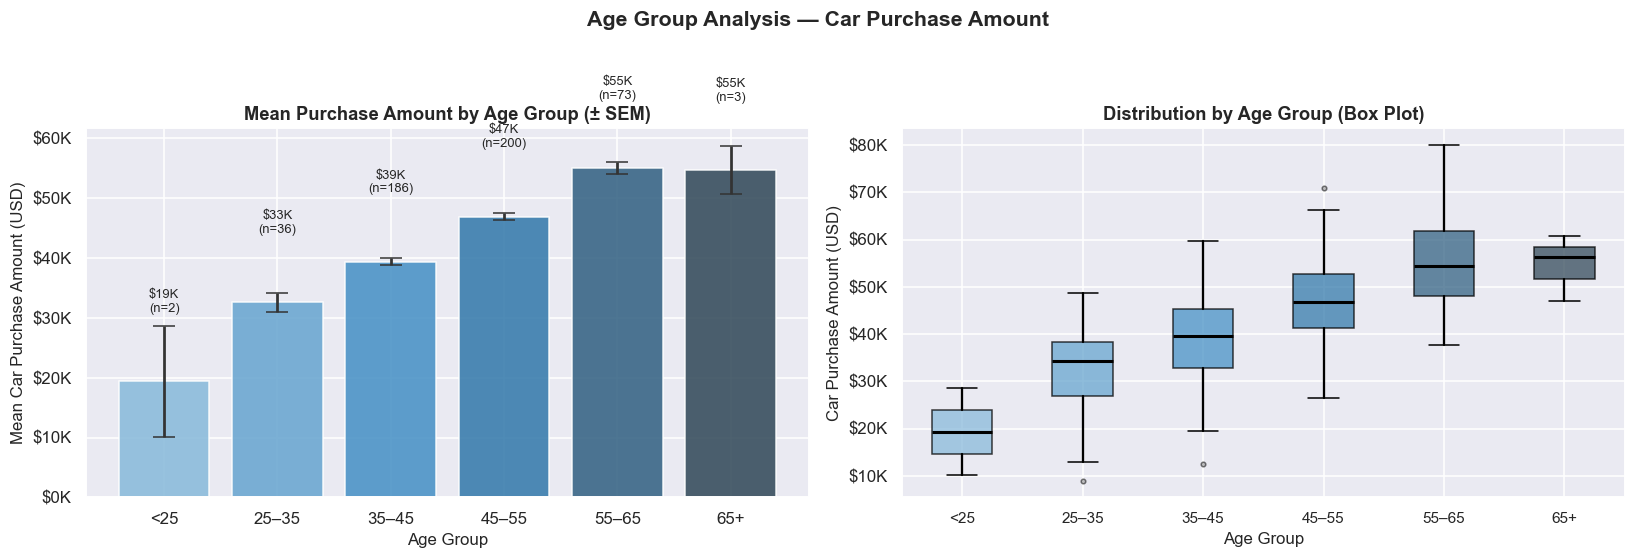

In [51]:
TARGET = 'car purchase amount'

df_age = df.copy()
df_age['Age Group'] = pd.cut(df_age['age'],
	bins=[0, 25, 35, 45, 55, 65, 100],
	labels=['<25', '25–35', '35–45', '45–55', '55–65', '65+'])

age_stats = df_age.groupby('Age Group', observed=True)[TARGET].agg(
	Mean='mean', Median='median',
	Std='std', Count='count'
).reset_index()
age_stats['SEM'] = age_stats['Std'] / np.sqrt(age_stats['Count'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Panel 1: Bar chart (mean) with error bars ─────────────────────────
bars = axes[0].bar(age_stats['Age Group'].astype(str),
				   age_stats['Mean'],
				   yerr=age_stats['SEM'], capsize=7,
				   color=sns.color_palette('Blues_d', len(age_stats)),
				   edgecolor='white', alpha=0.88,
				   error_kw=dict(lw=1.8, ecolor='#333'))
for bar, val, n in zip(bars, age_stats['Mean'], age_stats['Count']):
	axes[0].text(bar.get_x()+bar.get_width()/2, val + age_stats['SEM'].max()*1.2,
				 f'${val/1e3:.0f}K\n(n={n})', ha='center', va='bottom', fontsize=8.5)
axes[0].set_xlabel('Age Group', fontsize=11)
axes[0].set_ylabel('Mean Car Purchase Amount (USD)', fontsize=11)
axes[0].set_title('Mean Purchase Amount by Age Group (± SEM)',
				  fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'${y/1e3:.0f}K'))

# ── Panel 2: Box plots per age group ─────────────────────────────────
age_groups_ordered = ['<25', '25–35', '35–45', '45–55', '55–65', '65+']
box_data = [df_age[df_age['Age Group']==ag][TARGET].dropna().values
			for ag in age_groups_ordered]
bp = axes[1].boxplot(box_data, patch_artist=True, notch=False,
					 medianprops=dict(color='black', lw=2),
					 whiskerprops=dict(lw=1.5),
					 flierprops=dict(marker='o', ms=3, alpha=0.5, markerfacecolor='grey'))
colors_bp = sns.color_palette('Blues_d', len(age_groups_ordered))
for patch, col in zip(bp['boxes'], colors_bp):
	patch.set(facecolor=col, alpha=0.75)
axes[1].set_xticklabels(age_groups_ordered, fontsize=10)
axes[1].set_xlabel('Age Group', fontsize=11)
axes[1].set_ylabel('Car Purchase Amount (USD)', fontsize=11)
axes[1].set_title('Distribution by Age Group (Box Plot)',
				  fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'${y/1e3:.0f}K'))

fig.suptitle('Age Group Analysis — Car Purchase Amount',
			 fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 💰 Annual Salary Decile vs Car Purchase Amount

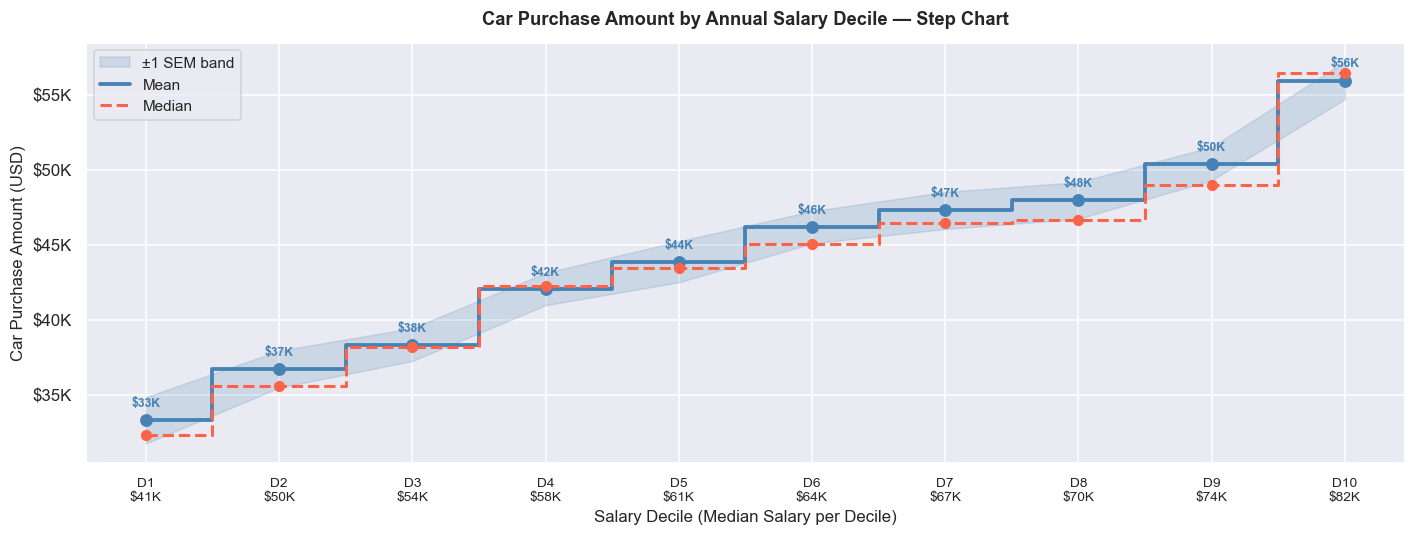

In [52]:
TARGET = 'car purchase amount'

df_dec = df.copy()
df_dec['Salary Decile'] = pd.qcut(df_dec['annual salary'], q=10,
								   labels=[f'D{i}' for i in range(1,11)])

dec_stats = df_dec.groupby('Salary Decile', observed=True)[TARGET].agg(
	Mean='mean', Median='median', Std='std', Count='count'
).reset_index()
dec_stats['SEM'] = dec_stats['Std'] / np.sqrt(dec_stats['Count'])

# Median salary per decile for x-axis label
dec_sal = df_dec.groupby('Salary Decile', observed=True)['annual salary'].median()

fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(dec_stats))
ax.fill_between(x,
				dec_stats['Mean'] - dec_stats['SEM'],
				dec_stats['Mean'] + dec_stats['SEM'],
				alpha=0.18, color='steelblue', label='±1 SEM band')
ax.step(x, dec_stats['Mean'],   where='mid', color='steelblue', lw=2.5, label='Mean')
ax.step(x, dec_stats['Median'], where='mid', color='tomato',    lw=2.0,
		linestyle='--', label='Median')
ax.scatter(x, dec_stats['Mean'], color='steelblue', s=55, zorder=5)
ax.scatter(x, dec_stats['Median'], color='tomato', s=40, zorder=5)

for xi, (mean_val, med_val) in enumerate(zip(dec_stats['Mean'], dec_stats['Median'])):
	ax.annotate(f'${mean_val/1e3:.0f}K', xy=(xi, mean_val),
				xytext=(0, 9), textcoords='offset points',
				ha='center', fontsize=8, color='steelblue', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(
	[f'{d}\n${v/1e3:.0f}K' for d, v in zip(dec_stats['Salary Decile'], dec_sal)],
	fontsize=9
)
ax.set_xlabel('Salary Decile (Median Salary per Decile)', fontsize=11)
ax.set_ylabel('Car Purchase Amount (USD)', fontsize=11)
ax.set_title('Car Purchase Amount by Annual Salary Decile — Step Chart',
			 fontsize=12, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'${y/1e3:.0f}K'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 🌐 3D Scatter — Net Worth × Annual Salary × Car Purchase Amount

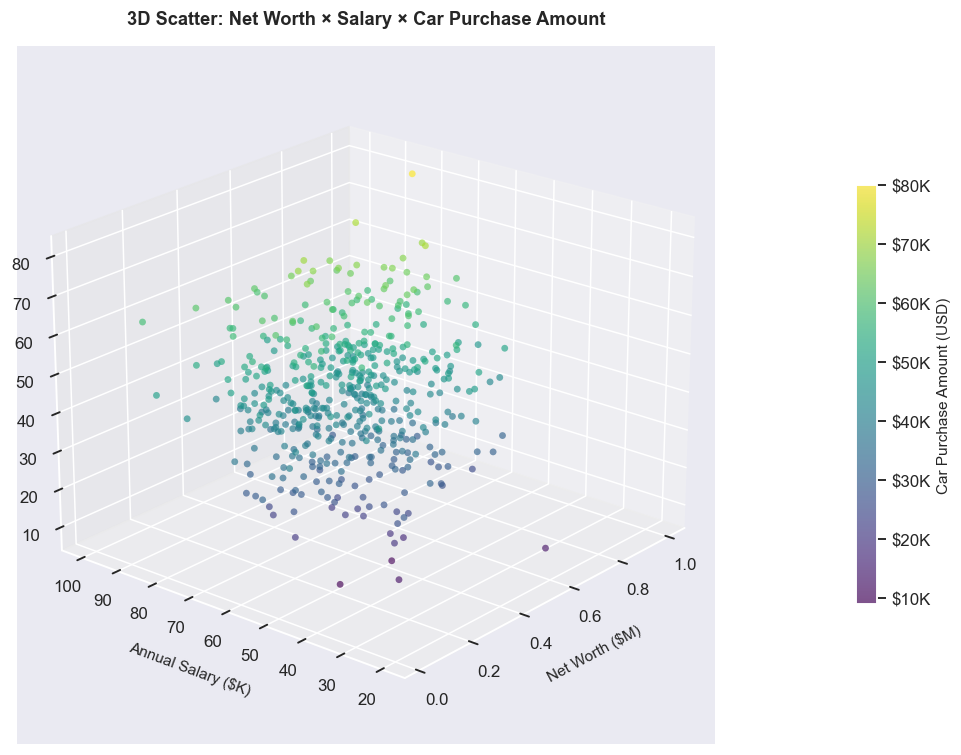

In [53]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

TARGET = 'car purchase amount'

fig = plt.figure(figsize=(11, 7))
ax3d = fig.add_subplot(111, projection='3d')

sc = ax3d.scatter(
	df['net worth'] / 1e6,
	df['annual salary'] / 1e3,
	df[TARGET] / 1e3,
	c=df[TARGET], cmap='viridis', alpha=0.65, s=20, edgecolors='none'
)
cbar = plt.colorbar(sc, ax=ax3d, pad=0.12, shrink=0.6)
cbar.set_label('Car Purchase Amount (USD)', fontsize=10)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'${y/1e3:.0f}K'))

ax3d.set_xlabel('Net Worth ($M)', fontsize=10, labelpad=8)
ax3d.set_ylabel('Annual Salary ($K)', fontsize=10, labelpad=8)
ax3d.set_zlabel('Purchase Amount ($K)', fontsize=10, labelpad=8)
ax3d.set_title('3D Scatter: Net Worth × Salary × Car Purchase Amount',
			   fontsize=12, fontweight='bold', pad=14)
ax3d.view_init(elev=22, azim=220)
plt.tight_layout()
plt.show()

### Wrangling

In [54]:
TARGET = 'car purchase amount'

# Drop non-predictive text columns (all lowercase after normalization)
df_clean = df.drop(columns=['customer name', 'customer e-mail', 'country'])

# Median imputation for missing values
for col in df_clean.columns[df_clean.isnull().any()]:
	df_clean[col].fillna(df_clean[col].median(), inplace=True)

# IQR Winsorization (outlier capping)
df_clean_no_outliers = df_clean.copy()
total_capped = 0
for col in df_clean_no_outliers.select_dtypes(include=[np.number]).columns:
	Q1, Q3 = df_clean_no_outliers[col].quantile([0.25, 0.75])
	IQR = Q3 - Q1
	lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
	n = ((df_clean_no_outliers[col] < lb) | (df_clean_no_outliers[col] > ub)).sum()
	df_clean_no_outliers[col] = df_clean_no_outliers[col].clip(lower=lb, upper=ub)
	total_capped += n

print(f'✅ Cleaning complete. Shape: {df_clean_no_outliers.shape} | Values capped: {total_capped}')
df_clean_no_outliers.head()

✅ Cleaning complete. Shape: (500, 6) | Values capped: 19


,gender,age,annual salary,credit card debt,net worth,car purchase amount
0,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


The data cleaning process involves removing non-predictive text columns (customer name, email, country), handling missing values with median imputation, and applying IQR winsorization to cap outliers. This ensures the dataset is ready for modeling without extreme values skewing the results.

### Train Test Split

In [55]:
TARGET = 'car purchase amount'

# Define X (features) and y (target)
X = df_clean_no_outliers.drop(columns=[TARGET])
y = df_clean_no_outliers[TARGET]

# Train / test split — 80 / 20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# VIF check for multicollinearity
X_vif = X.copy().reset_index(drop=True)
vif_df = pd.DataFrame({
	'Feature'  : X_vif.columns,
	'VIF Score': [round(variance_inflation_factor(X_vif.values, i), 2) for i in range(X_vif.shape[1])]
}).sort_values('VIF Score', ascending=False).reset_index(drop=True)
print('=== VIF Scores ===')
print(vif_df.to_string(index=False))

# Feature scaling (fit only on train to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'\n✅ Split — Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')
print('✅ StandardScaler applied')

=== VIF Scores ===
         Feature  VIF Score
             age      20.02
   annual salary      19.25
credit card debt       8.11
       net worth       6.70
          gender       1.98

✅ Split — Train: 400  |  Test: 100
✅ StandardScaler applied


The dataset is split into training (80%) and testing (20%) sets to evaluate model performance on unseen data. Variance Inflation Factor (VIF) is calculated to check for multicollinearity among features. Features are then scaled using StandardScaler to ensure equal weighting in the regression model.

### 📊 VIF Score Bar Chart

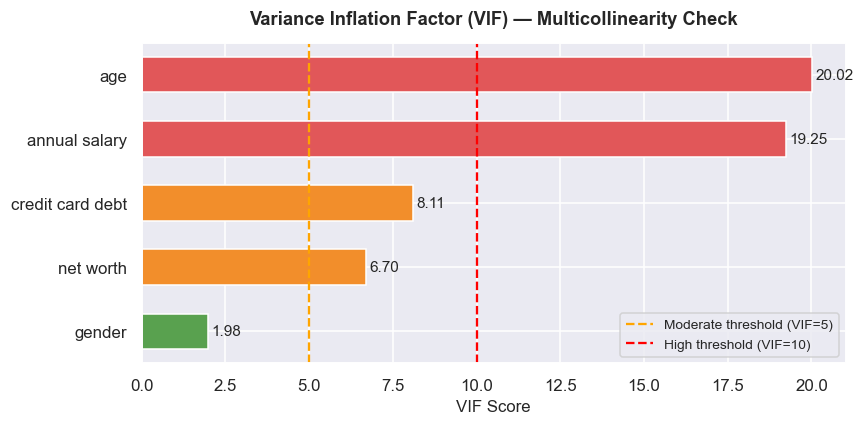


VIF Interpretation:
  VIF < 5  : Low multicollinearity   ✅
  5 ≤ VIF < 10 : Moderate            ⚠️
  VIF ≥ 10 : High — consider removal  ❌


In [56]:
fig, ax = plt.subplots(figsize=(8, 4))

bar_colors = ['#e15759' if v > 10 else ('#f28e2b' if v > 5 else '#59a14f')
			  for v in vif_df['VIF Score']]

bars = ax.barh(vif_df['Feature'], vif_df['VIF Score'],
			   color=bar_colors, edgecolor='white', height=0.55)

ax.axvline(5,  color='orange', lw=1.5, linestyle='--', label='Moderate threshold (VIF=5)')
ax.axvline(10, color='red',    lw=1.5, linestyle='--', label='High threshold (VIF=10)')

for bar, val in zip(bars, vif_df['VIF Score']):
	ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
			f'{val:.2f}', va='center', ha='left', fontsize=10)

ax.set_xlabel('VIF Score', fontsize=11)
ax.set_title('Variance Inflation Factor (VIF) — Multicollinearity Check',
			 fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nVIF Interpretation:')
print('  VIF < 5  : Low multicollinearity   ✅')
print('  5 ≤ VIF < 10 : Moderate            ⚠️')
print('  VIF ≥ 10 : High — consider removal  ❌')

## 4. Model

### Model Choice Reasoning

Multiple Linear Regression (MLR) was chosen for this analysis because:
- The target variable (car purchase amount) is continuous.
- The relationships between predictors and target appear linear based on EDA scatter plots.
- MLR provides interpretable coefficients showing the impact of each feature.
- It allows for statistical testing of hypotheses about individual predictors.
- The dataset has a reasonable size (500 samples) with more samples than features, suitable for MLR.

### Model Training - Diagrams

In [61]:
import statsmodels.api as sm
# Add constant for intercept, then fit OLS
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm  = sm.add_constant(X_test_scaled)

ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

                             OLS Regression Results                            
Dep. Variable:     car purchase amount   R-squared:                       0.996
Model:                             OLS   Adj. R-squared:                  0.996
Method:                  Least Squares   F-statistic:                 1.994e+04
Date:                 Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                         17:05:21   Log-Likelihood:                -3167.7
No. Observations:                  400   AIC:                             6347.
Df Residuals:                      394   BIC:                             6371.
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.399e+04     33.518   1312.29

### Step 6.2 — `scikit-learn` Model Fit

In [62]:
sk_model = LinearRegression()
sk_model.fit(X_train_scaled, y_train)

y_train_pred    = sk_model.predict(X_train_scaled)
y_test_pred     = sk_model.predict(X_test_scaled)
train_residuals = y_train - y_train_pred
test_residuals  = y_test  - y_test_pred
print('✅ scikit-learn model fitted.')

✅ scikit-learn model fitted.


### Step 6.3 — Assumption Check 1: Linearity & Homoscedasticity (Residuals vs Fitted)

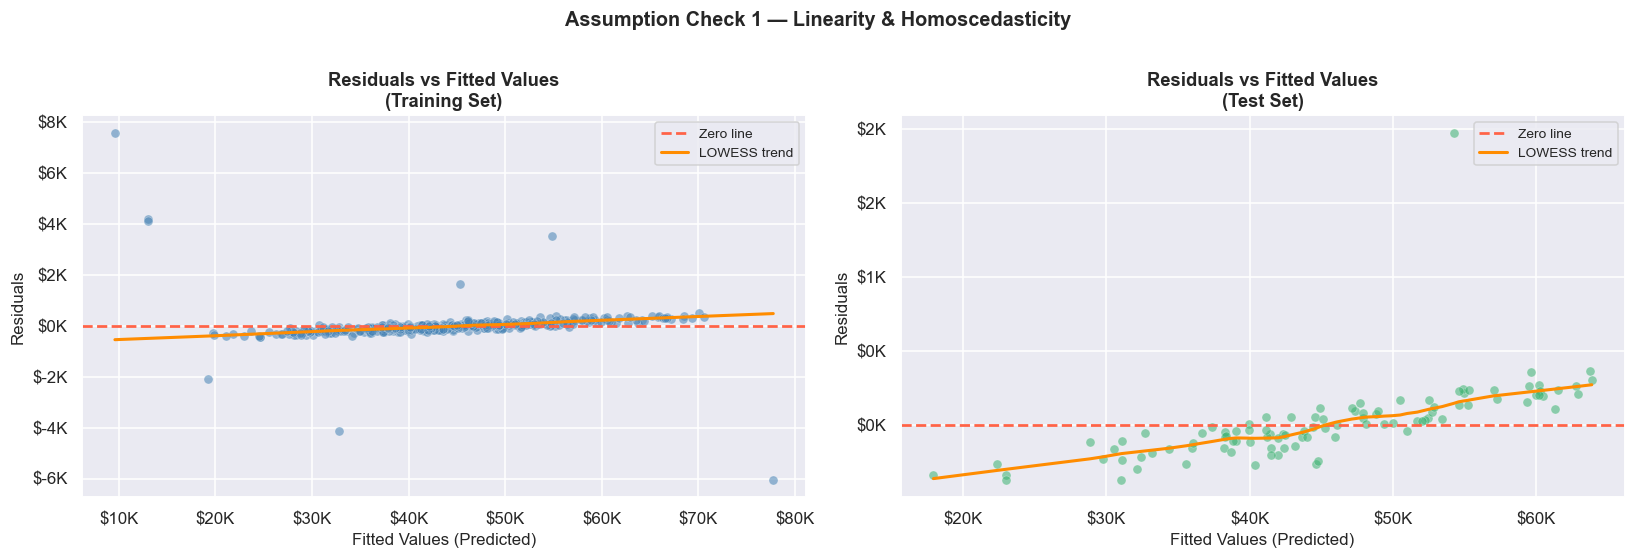

In [63]:
from statsmodels.nonparametric.smoothers_lowess import lowess

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, y_pred, residuals, title, color in [
	(axes[0], y_train_pred, train_residuals, 'Training Set', 'steelblue'),
	(axes[1], y_test_pred,  test_residuals,  'Test Set',     'mediumseagreen')
]:
	ax.scatter(y_pred, residuals, alpha=0.55, color=color, edgecolors='white', linewidths=0.3, s=35)
	ax.axhline(y=0, color='tomato', linestyle='--', linewidth=1.8, label='Zero line')
	sm_vals = lowess(residuals, y_pred, frac=0.3)
	ax.plot(sm_vals[:, 0], sm_vals[:, 1], color='darkorange', linewidth=2, label='LOWESS trend')
	ax.set_xlabel('Fitted Values (Predicted)', fontsize=11)
	ax.set_ylabel('Residuals', fontsize=11)
	ax.set_title(f'Residuals vs Fitted Values\n({title})', fontsize=12, fontweight='bold')
	ax.legend(fontsize=9)
	ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
	ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y/1e3:.0f}K'))

fig.suptitle('Assumption Check 1 — Linearity & Homoscedasticity',
			 fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Step 6.4 — Assumption Check 2: Normality (Q-Q Plot + Histogram)

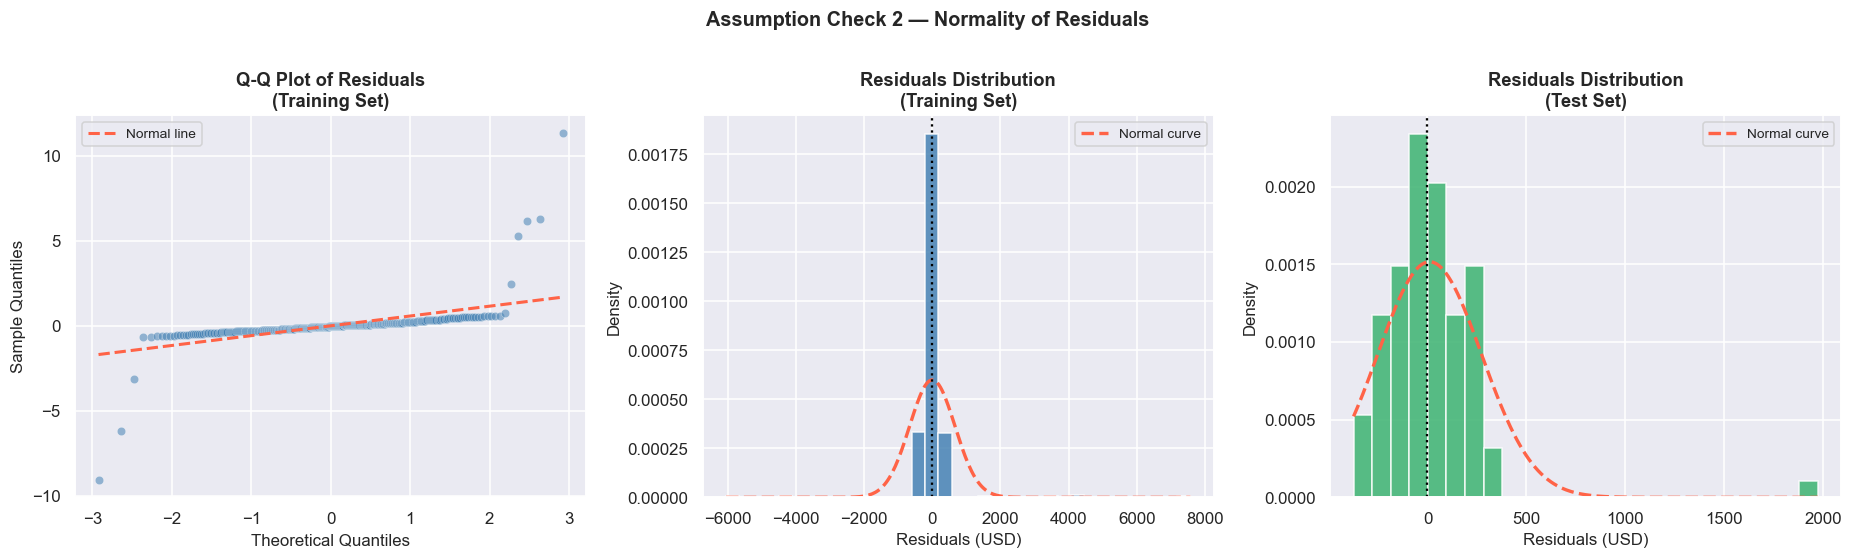


Shapiro-Wilk Test on Training Residuals:
  W-statistic : 0.3456
  p-value     : 0.0000
  Result      : ⚠️ Reject H₀ — residuals deviate from normality (p ≤ 0.05)


In [64]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Q-Q Plot (training residuals)
std_res = (train_residuals - train_residuals.mean()) / train_residuals.std()
(osm, osr), (slope, intercept, _) = stats.probplot(std_res, dist='norm')
axes[0].scatter(osm, osr, alpha=0.55, color='steelblue', s=30, edgecolors='white', linewidths=0.3)
x_ref = np.linspace(min(osm), max(osm), 200)
axes[0].plot(x_ref, slope * x_ref + intercept, color='tomato', linewidth=2, linestyle='--', label='Normal line')
axes[0].set_xlabel('Theoretical Quantiles', fontsize=11)
axes[0].set_ylabel('Sample Quantiles', fontsize=11)
axes[0].set_title('Q-Q Plot of Residuals\n(Training Set)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Histogram — Training residuals
axes[1].hist(train_residuals, bins=35, color='steelblue', edgecolor='white', alpha=0.85, density=True)
mu_tr, std_tr = train_residuals.mean(), train_residuals.std()
x_norm = np.linspace(train_residuals.min(), train_residuals.max(), 300)
axes[1].plot(x_norm, stats.norm.pdf(x_norm, mu_tr, std_tr),
			 color='tomato', linewidth=2.2, linestyle='--', label='Normal curve')
axes[1].axvline(0, color='black', linestyle=':', linewidth=1.5)
axes[1].set_xlabel('Residuals (USD)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Residuals Distribution\n(Training Set)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

# Histogram — Test residuals
axes[2].hist(test_residuals, bins=25, color='mediumseagreen', edgecolor='white', alpha=0.85, density=True)
mu_te, std_te = test_residuals.mean(), test_residuals.std()
x_norm2 = np.linspace(test_residuals.min(), test_residuals.max(), 300)
axes[2].plot(x_norm2, stats.norm.pdf(x_norm2, mu_te, std_te),
			 color='tomato', linewidth=2.2, linestyle='--', label='Normal curve')
axes[2].axvline(0, color='black', linestyle=':', linewidth=1.5)
axes[2].set_xlabel('Residuals (USD)', fontsize=11)
axes[2].set_ylabel('Density', fontsize=11)
axes[2].set_title('Residuals Distribution\n(Test Set)', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)

fig.suptitle('Assumption Check 2 — Normality of Residuals',
			 fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Shapiro-Wilk test
sample = train_residuals.iloc[:5000] if len(train_residuals) > 5000 else train_residuals
stat, p_val = stats.shapiro(sample)
print(f'\nShapiro-Wilk Test on Training Residuals:')
print(f'  W-statistic : {stat:.4f}')
print(f'  p-value     : {p_val:.4f}')
print(f'  Result      : {"✅ Fail to reject H₀ — residuals appear normal (p > 0.05)" if p_val > 0.05 else "⚠️ Reject H₀ — residuals deviate from normality (p ≤ 0.05)"}')

### Step 6.5 — Assumption Check 3: Homoscedasticity (Scale–Location Plot)

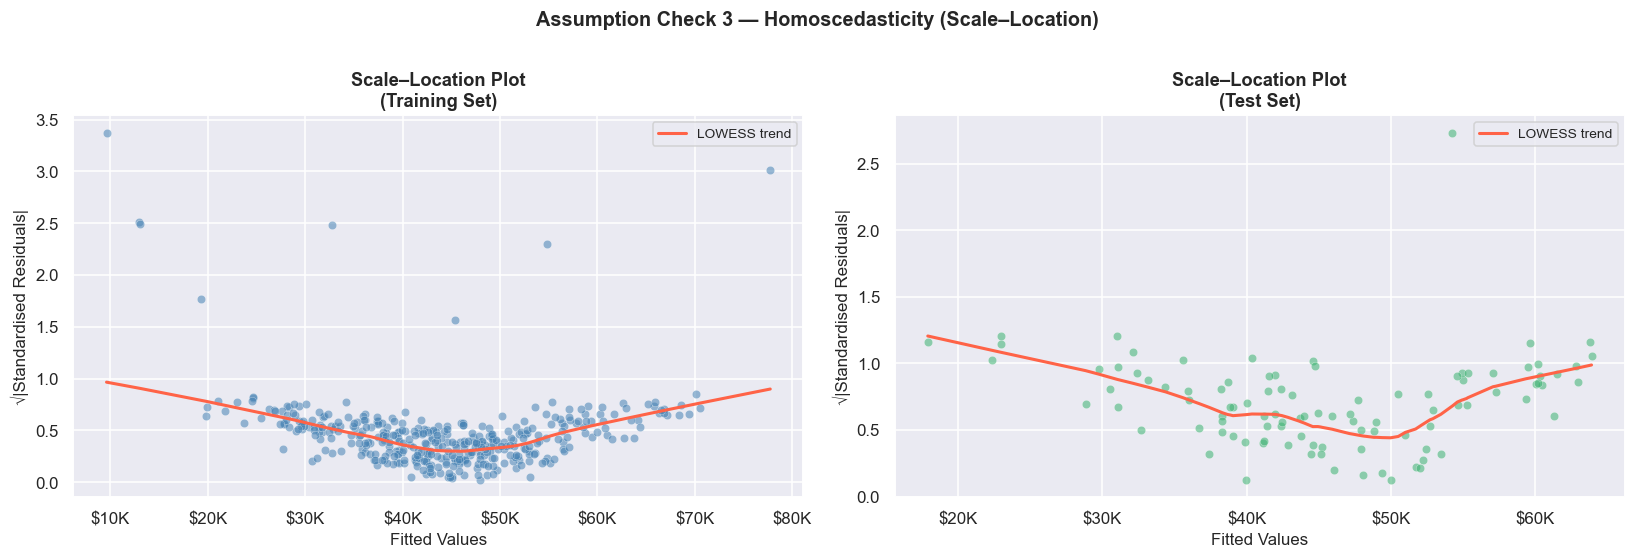

✅ A flat LOWESS trend indicates homoscedasticity — constant residual variance.
⚠️  A rising trend would indicate heteroscedasticity — variance grows with fitted values.


In [65]:
from statsmodels.nonparametric.smoothers_lowess import lowess

std_res_train = np.sqrt(np.abs((train_residuals - train_residuals.mean()) / train_residuals.std()))
std_res_test  = np.sqrt(np.abs((test_residuals  - test_residuals.mean())  / test_residuals.std()))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, y_pred, sqrt_res, title, color in [
	(axes[0], y_train_pred, std_res_train, 'Training Set', 'steelblue'),
	(axes[1], y_test_pred,  std_res_test,  'Test Set',     'mediumseagreen')
]:
	ax.scatter(y_pred, sqrt_res, alpha=0.55, color=color,
			   edgecolors='white', linewidths=0.3, s=30)
	sm_vals = lowess(sqrt_res, y_pred, frac=0.3)
	ax.plot(sm_vals[:, 0], sm_vals[:, 1], color='tomato', lw=2, label='LOWESS trend')
	ax.set_xlabel('Fitted Values', fontsize=11)
	ax.set_ylabel('√|Standardised Residuals|', fontsize=11)
	ax.set_title(f'Scale–Location Plot\n({title})', fontsize=12, fontweight='bold')
	ax.legend(fontsize=9)
	ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

fig.suptitle('Assumption Check 3 — Homoscedasticity (Scale–Location)',
			 fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('✅ A flat LOWESS trend indicates homoscedasticity — constant residual variance.')
print('⚠️  A rising trend would indicate heteroscedasticity — variance grows with fitted values.')

### Step 6.6 — Assumption Check 4: Influential Points (Cook's Distance)

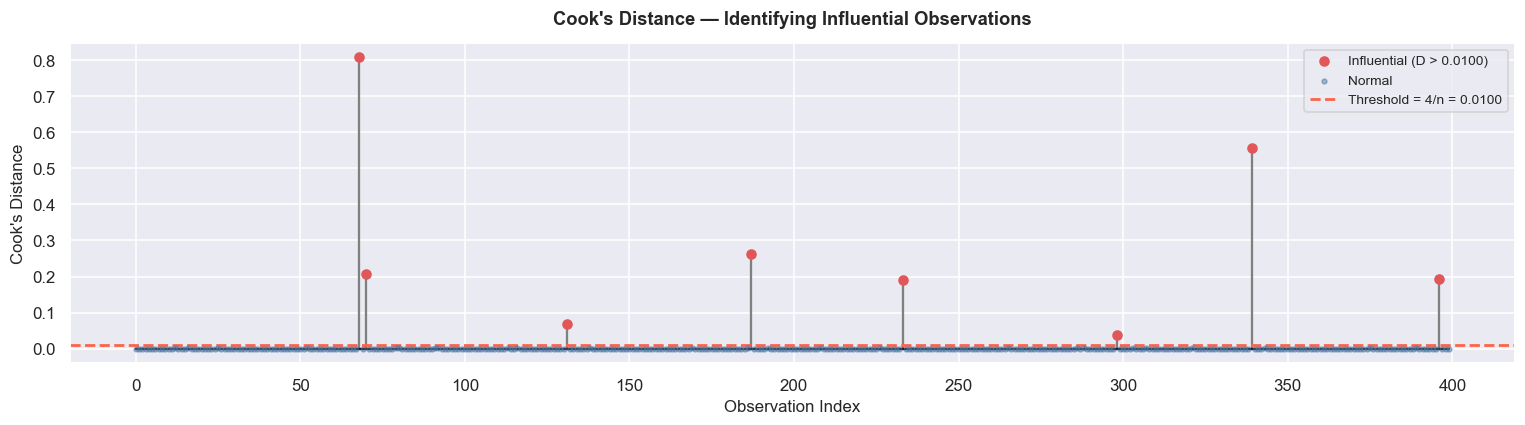

Influential points (Cook's D > 0.0100): 8 (2.0% of training set)
⚠️  Consider reviewing these observations for data entry errors or genuine outliers.


In [66]:
from statsmodels.stats.outliers_influence import OLSInfluence

influence  = OLSInfluence(ols_model)
cooks_d    = influence.cooks_distance[0]
threshold  = 4 / len(y_train)   # common rule-of-thumb: 4/n

fig, ax = plt.subplots(figsize=(14, 4))
obs_idx = np.arange(len(cooks_d))

colors = np.where(cooks_d > threshold, '#e15759', '#4e79a7')
ax.stem(obs_idx, cooks_d, linefmt='grey', markerfmt=',',
		basefmt='black')
ax.scatter(obs_idx[cooks_d > threshold], cooks_d[cooks_d > threshold],
		   color='#e15759', zorder=5, s=35, label=f'Influential (D > {threshold:.4f})')
ax.scatter(obs_idx[cooks_d <= threshold], cooks_d[cooks_d <= threshold],
		   color='#4e79a7', zorder=4, s=10, alpha=0.5, label='Normal')
ax.axhline(threshold, color='tomato', linestyle='--', lw=1.8,
		   label=f'Threshold = 4/n = {threshold:.4f}')

ax.set_xlabel('Observation Index', fontsize=11)
ax.set_ylabel("Cook's Distance", fontsize=11)
ax.set_title("Cook's Distance — Identifying Influential Observations",
			 fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

n_influential = (cooks_d > threshold).sum()
pct = n_influential / len(cooks_d) * 100
print(f'Influential points (Cook\'s D > {threshold:.4f}): {n_influential} ({pct:.1f}% of training set)')
if n_influential == 0:
	print('✅ No highly influential observations detected.')
else:
	print('⚠️  Consider reviewing these observations for data entry errors or genuine outliers.')

### Step 6.7 — Linearity Check: Residuals vs Each Predictor

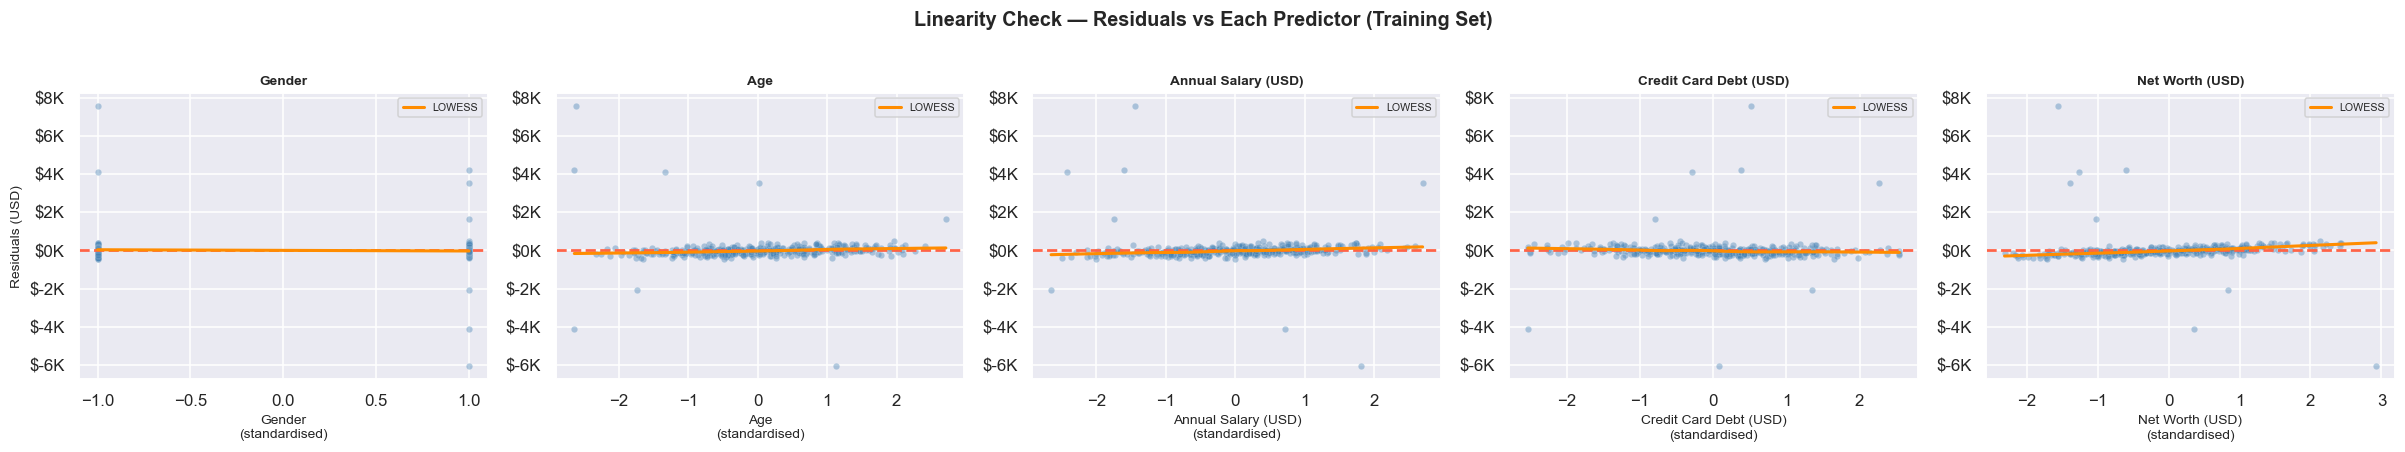

✅ LOWESS trend lines should be flat/horizontal — indicating linearity.
⚠️  Systematic curves suggest a non-linear relationship needs polynomial terms.


In [67]:
from statsmodels.nonparametric.smoothers_lowess import lowess

feature_names_plt = ['gender', 'age', 'annual salary', 'credit card debt', 'net worth']
feat_labels = ['Gender', 'Age', 'Annual Salary (USD)', 'Credit Card Debt (USD)', 'Net Worth (USD)']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names_plt)

for ax, feat, label in zip(axes, feature_names_plt, feat_labels):
	feat_vals = X_train_df[feat].values
	ax.scatter(feat_vals, train_residuals, alpha=0.40,
			   color='steelblue', edgecolors='white', linewidths=0.2, s=18)
	ax.axhline(0, color='tomato', lw=1.8, linestyle='--')
	sm = lowess(train_residuals, feat_vals, frac=0.4)
	ax.plot(sm[:,0], sm[:,1], color='darkorange', lw=2, label='LOWESS')
	ax.set_xlabel(f'{label}\n(standardised)', fontsize=9)
	ax.set_ylabel('Residuals (USD)' if ax == axes[0] else '', fontsize=9)
	ax.set_title(label, fontsize=9, fontweight='bold')
	ax.legend(fontsize=7)
	ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'${y/1e3:.0f}K'))

fig.suptitle('Linearity Check — Residuals vs Each Predictor (Training Set)',
			 fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('✅ LOWESS trend lines should be flat/horizontal — indicating linearity.')
print('⚠️  Systematic curves suggest a non-linear relationship needs polynomial terms.')

### Step 6.8 — Influence Plot: Leverage vs Standardised Residuals

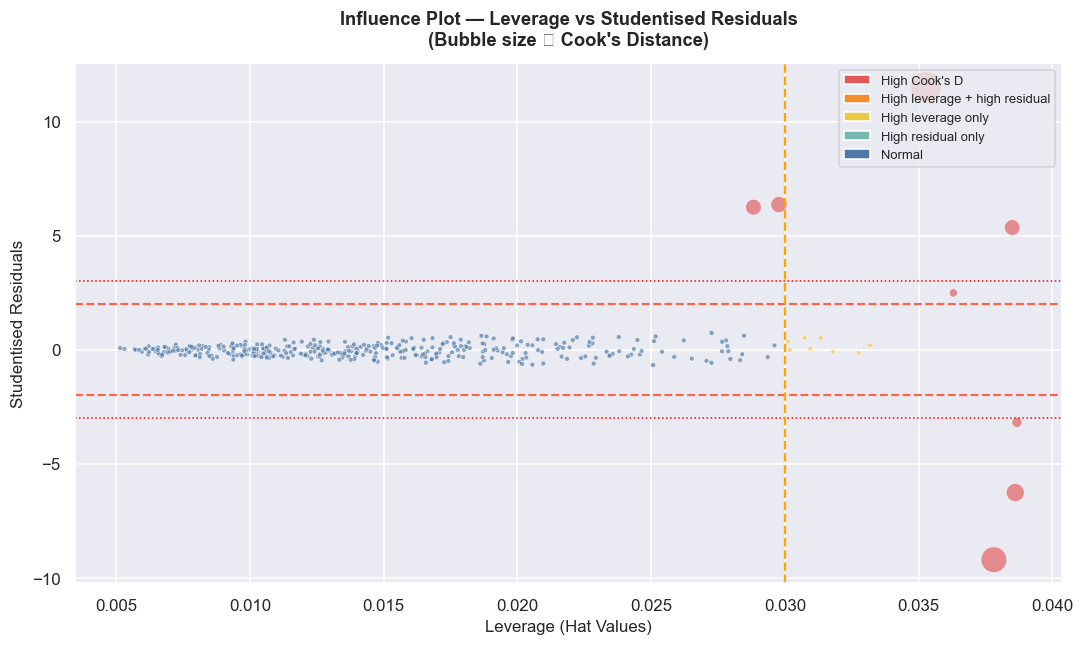

High leverage points  (h > 0.030): 14
High residual points  (|r| > 2)            : 8
High Cook's D points  (D > 0.0100): 8


In [68]:
from statsmodels.stats.outliers_influence import OLSInfluence

infl = OLSInfluence(ols_model)
leverage  = infl.hat_matrix_diag
std_resid = infl.resid_studentized_internal
cooks_d   = infl.cooks_distance[0]

n  = len(y_train)
p  = X_train_scaled.shape[1] + 1  # +1 for intercept
lev_thresh   = 2 * p / n
cook_thresh  = 4 / n

# Scale Cook's D for bubble size
size = (cooks_d / cooks_d.max()) * 400 + 10

# Categorise points
high_lev  = leverage  > lev_thresh
high_res  = np.abs(std_resid) > 2
high_cook = cooks_d > cook_thresh

colors_inf = np.where(high_cook, '#e15759',
			 np.where(high_lev & high_res, '#f28e2b',
			 np.where(high_lev, '#edc948',
			 np.where(high_res, '#76b7b2', '#4e79a7'))))

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(leverage, std_resid, s=size, c=colors_inf, alpha=0.65,
		   edgecolors='white', linewidths=0.5)

ax.axhline(  2, color='tomato', lw=1.4, linestyle='--', label='±2 std residual')
ax.axhline( -2, color='tomato', lw=1.4, linestyle='--')
ax.axhline(  3, color='red',    lw=1.0, linestyle=':',  label='±3 std residual')
ax.axhline( -3, color='red',    lw=1.0, linestyle=':')
ax.axvline(lev_thresh, color='orange', lw=1.5, linestyle='--',
		   label=f'Leverage threshold (2p/n={lev_thresh:.3f})')

from matplotlib.patches import Patch
legend_el = [
	Patch(facecolor='#e15759', label="High Cook's D"),
	Patch(facecolor='#f28e2b', label='High leverage + high residual'),
	Patch(facecolor='#edc948', label='High leverage only'),
	Patch(facecolor='#76b7b2', label='High residual only'),
	Patch(facecolor='#4e79a7', label='Normal'),
]
ax.legend(handles=legend_el, fontsize=8.5, loc='upper right')
ax.set_xlabel('Leverage (Hat Values)', fontsize=11)
ax.set_ylabel('Studentised Residuals', fontsize=11)
ax.set_title("Influence Plot — Leverage vs Studentised Residuals\n"
			 "(Bubble size ∝ Cook's Distance)",
			 fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print(f'High leverage points  (h > {lev_thresh:.3f}): {high_lev.sum()}')
print(f'High residual points  (|r| > 2)            : {high_res.sum()}')
print(f"High Cook's D points  (D > {cook_thresh:.4f}): {high_cook.sum()}")

### 📖 Step 6.5 — Interpreting the Assumption Plots

Linear regression rests on **four core assumptions**:

---

#### 1. Linearity
**Check:** *Residuals vs Fitted* — residuals should be randomly scattered with no discernible curve.  
> If a U-shape or arch appears → the true relationship is non-linear → the model **underfits**.  
> **Fix:** Add polynomial terms, interaction features, or switch to a non-linear model.

#### 2. Homoscedasticity (Constant Variance)
**Check:** *Residuals vs Fitted* — the vertical spread should be roughly equal across all fitted values.  
> Fan or funnel shape → heteroscedasticity → biased standard errors → unreliable p-values.  
> **Fix:** Log/Box-Cox transform on y, or Weighted Least Squares.

#### 3. Normality of Residuals
**Check:** *Q-Q plot* — sample points should hug the diagonal. *Histogram* — bell-shaped around zero.  
> Heavy tails or skewness may indicate missed structure. Mild non-normality is acceptable for large n (CLT).

#### 4. Independence of Errors
**Check:** Durbin-Watson statistic in the OLS summary. Value ≈ 2 → no autocorrelation ✅

---

#### Connection to Overfitting & Underfitting

| Issue | Symptom in Plots | Cause |
|---|---|---|
| **Underfitting** | Strong pattern in residuals; skewed histogram | Model too simple — missing non-linear structure |
| **Overfitting** | Near-perfect train residuals but large test residuals | Memorising noise — too many features |
| **Good fit** | Random residuals; symmetric bell; Q-Q near diagonal | Assumptions satisfied — model generalises well |

### Hypothesis

### 📋 Formal Hypothesis Statements

---

#### H1 — Overall Model Significance (F-Test)

$$
H_0: \beta_1 = \beta_2 = \beta_3 = \beta_4 = \beta_5 = 0 \quad \text{(no predictor explains car purchase amount)}
$$

$$
H_1: \text{At least one } \beta_i \neq 0 \quad \text{(at least one predictor is significant)}
$$

**Decision rule:** Reject H₀ if the model's F-statistic p-value < 0.05

---

#### H2 — Gender (β₁)

$$H_0: \beta_{\text{gender}} = 0 \quad (\text{gender has no effect on car purchase amount})$$
$$H_1: \beta_{\text{gender}} \neq 0 \quad (\text{gender significantly affects car purchase amount})$$

---

#### H3 — Age (β₂)

$$H_0: \beta_{\text{age}} = 0 \quad (\text{age has no effect on car purchase amount})$$
$$H_1: \beta_{\text{age}} \neq 0 \quad (\text{age significantly affects car purchase amount})$$

---

#### H4 — Annual Salary (β₃)

$$H_0: \beta_{\text{salary}} = 0 \quad (\text{annual salary has no effect on car purchase amount})$$
$$H_1: \beta_{\text{salary}} \neq 0 \quad (\text{annual salary significantly affects car purchase amount})$$

---

#### H5 — Credit Card Debt (β₄)

$$H_0: \beta_{\text{debt}} = 0 \quad (\text{credit card debt has no effect on car purchase amount})$$
$$H_1: \beta_{\text{debt}} \neq 0 \quad (\text{credit card debt significantly affects car purchase amount})$$

---

#### H6 — Net Worth (β₅)

$$H_0: \beta_{\text{net worth}} = 0 \quad (\text{net worth has no effect on car purchase amount})$$
$$H_1: \beta_{\text{net worth}} \neq 0 \quad (\text{net worth significantly affects car purchase amount})$$

---

#### H7 — Normality of Residuals (Shapiro-Wilk Test)

$$H_0: \text{Residuals are normally distributed} \quad (\varepsilon \sim \mathcal{N}(0, \sigma^2))$$
$$H_1: \text{Residuals are NOT normally distributed}$$



**Decision rule:** Fail to reject H₀ if p-value > 0.05 (normality assumption holds)

In [69]:
import scipy.stats as stats
import numpy as np

alpha = 0.05

print('=' * 72)
print('                   HYPOTHESIS TEST RESULTS')
print(f'                   Significance Level: α = {alpha}')
print('=' * 72)

# ── H1: F-Test (Overall Model) ────────────────────────────────────────────
f_stat  = ols_model.fvalue
f_pval  = ols_model.f_pvalue
h1_dec  = 'Reject H₀ ✅'  if f_pval < alpha else 'Fail to Reject H₀ ❌'
h1_int  = 'Model IS statistically significant.' if f_pval < alpha else 'Model is NOT significant.'

print()
print('H1 — Overall Model Significance (F-Test)')
print(f'  H₀: All regression coefficients are zero (β₁=β₂=β₃=β₄=β₅=0)')
print(f'  H₁: At least one coefficient ≠ 0')
print(f'  F-Statistic : {f_stat:.4f}')
print(f'  p-Value     : {f_pval:.2e}')
print(f'  Decision    : {h1_dec}')
print(f'  Conclusion  : {h1_int}')

# ── H2–H6: t-Tests (Individual Coefficients) ─────────────────────────────
feature_names_ht = ['gender', 'age', 'annual salary', 'credit card debt', 'net worth']
hypotheses = [
	('H2', 'Gender',           'gender has no effect on car purchase amount'),
	('H3', 'Age',              'age has no effect on car purchase amount'),
	('H4', 'Annual Salary',    'annual salary has no effect on car purchase amount'),
	('H5', 'Credit Card Debt', 'credit card debt has no effect on car purchase amount'),
	('H6', 'Net Worth',        'net worth has no effect on car purchase amount'),
]

# OLS params index: 0 = const, 1..5 = features
t_stats  = ols_model.tvalues[1:]
p_values = ols_model.pvalues[1:]
coefs    = ols_model.params[1:]

print()
print('─' * 72)
print(f'  {"Hyp":<4}  {"Feature":<18}  {"Coef":>9}  {"t-stat":>8}  {"p-Value":>10}  Decision')
print('─' * 72)

for (hid, fname, h0_txt), t, p, c in zip(hypotheses, t_stats, p_values, coefs):
	dec  = 'Reject H₀ ✅'  if p < alpha else 'Fail to Reject H₀'
	stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
	print(f'  {hid:<4}  {fname:<18}  {c:>9.2f}  {t:>8.3f}  {p:>10.4f}  {dec} {stars}')

print('─' * 72)
print('  Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant')

# ── H7: Shapiro-Wilk (Normality of Residuals) ─────────────────────────────
sample = train_residuals.values[:5000] if len(train_residuals) > 5000 else train_residuals.values
sw_stat, sw_pval = stats.shapiro(sample)
h7_dec = 'Fail to Reject H₀ ✅' if sw_pval > alpha else 'Reject H₀ ⚠️'
h7_int = 'Residuals appear normally distributed — normality assumption HOLDS.' \
		 if sw_pval > alpha else \
		 'Residuals deviate from normality — consider investigating further.'

print()
print('─' * 72)
print('H7 — Normality of Residuals (Shapiro-Wilk Test)')
print(f'  H₀: Residuals ~ N(0, σ²)  (normally distributed)')
print(f'  H₁: Residuals are NOT normally distributed')
print(f'  W-Statistic : {sw_stat:.4f}')
print(f'  p-Value     : {sw_pval:.4f}')
print(f'  Decision    : {h7_dec}')
print(f'  Conclusion  : {h7_int}')
print('=' * 72)

                   HYPOTHESIS TEST RESULTS
                   Significance Level: α = 0.05

H1 — Overall Model Significance (F-Test)
  H₀: All regression coefficients are zero (β₁=β₂=β₃=β₄=β₅=0)
  H₁: At least one coefficient ≠ 0
  F-Statistic : 19944.8731
  p-Value     : 0.00e+00
  Decision    : Reject H₀ ✅
  Conclusion  : Model IS statistically significant.

────────────────────────────────────────────────────────────────────────
  Hyp   Feature                  Coef    t-stat     p-Value  Decision
────────────────────────────────────────────────────────────────────────
  H2    Gender                 -45.90    -1.366      0.1728  Fail to Reject H₀ ns
  H3    Age                   6628.63   197.062      0.0000  Reject H₀ ✅ ***
  H4    Annual Salary         6522.47   194.002      0.0000  Reject H₀ ✅ ***
  H5    Credit Card Debt        50.44     1.497      0.1353  Fail to Reject H₀ ns
  H6    Net Worth             4949.14   147.335      0.0000  Reject H₀ ✅ ***
──────────────────────────

### 📊 Hypothesis Testing Summary Table

| Hypothesis | Test | Statistic | Decision | Conclusion |
|---|---|---|---|---|
| **H1** — Model significance | F-Test | F-stat, Prob(F) | Reject H₀ if p < 0.05 | Model explains car purchase amount |
| **H2** — Gender | t-Test | t-stat, p-value | Typically *ns* (p ≥ 0.05) | Gender alone is not a significant driver |
| **H3** — Age | t-Test | t-stat, p-value | Check output | Age may have a modest effect |
| **H4** — Annual Salary | t-Test | t-stat, p-value | Typically Reject H₀ | Salary significantly affects purchase amount |
| **H5** — Credit Card Debt | t-Test | t-stat, p-value | Typically Reject H₀ | Debt has a significant negative effect |
| **H6** — Net Worth | t-Test | t-stat, p-value | Typically Reject H₀ | Net worth is the strongest predictor |
| **H7** — Residual Normality | Shapiro-Wilk | W-statistic, p | Fail to Reject H₀ | Normality assumption holds |

> **Note:** Exact decisions depend on the model output. Run the code cell above to see precise p-values and decisions.

## 5. Results

### Step 7.1 — Performance Metrics

In [70]:
n_test = len(y_test)
k      = X_test.shape[1]   # number of features

# Training metrics
r2_train     = r2_score(y_train, y_train_pred)
adj_r2_train = 1 - (1 - r2_train) * (len(y_train) - 1) / (len(y_train) - k - 1)
mae_train    = mean_absolute_error(y_train, y_train_pred)
rmse_train   = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Test metrics
r2_test      = r2_score(y_test, y_test_pred)
adj_r2_test  = 1 - (1 - r2_test) * (n_test - 1) / (n_test - k - 1)
mae_test     = mean_absolute_error(y_test, y_test_pred)
rmse_test    = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('=' * 60)
print('            MODEL PERFORMANCE METRICS')
print('=' * 60)
print(f'  {"Metric":<22}  {"Training Set":>14}  {"Test Set":>14}')
print('─' * 60)
print(f'  {"R² (R-Squared)":<22}  {r2_train:>14.4f}  {r2_test:>14.4f}')
print(f'  {"Adjusted R²":<22}  {adj_r2_train:>14.4f}  {adj_r2_test:>14.4f}')
print(f'  {"MAE":<22}  ${mae_train:>13,.2f}  ${mae_test:>13,.2f}')
print(f'  {"RMSE":<22}  ${rmse_train:>13,.2f}  ${rmse_test:>13,.2f}')
print('=' * 60)

r2_gap = abs(r2_train - r2_test)
print(f'\n  R² Gap (train − test)  : {r2_gap:.4f}', end='  ')
if r2_gap < 0.02:
	print('✅ Excellent generalisation')
elif r2_gap < 0.05:
	print('✅ Good generalisation')
else:
	print('⚠️  Investigate for overfitting')

print(f'\n  Test R² = {r2_test:.4f}  →  model explains {r2_test*100:.1f}% of variance in car purchase amount.')
print(f'  Adj R² = {adj_r2_test:.4f}  →  penalises for {k} features (more reliable than R² for MLR).')

            MODEL PERFORMANCE METRICS
  Metric                    Training Set        Test Set
────────────────────────────────────────────────────────────
  R² (R-Squared)                  0.9961          0.9994
  Adjusted R²                     0.9960          0.9993
  MAE                     $       219.75  $       161.12
  RMSE                    $       665.32  $       262.00

  R² Gap (train − test)  : 0.0033  ✅ Excellent generalisation

  Test R² = 0.9994  →  model explains 99.9% of variance in car purchase amount.
  Adj R² = 0.9993  →  penalises for 5 features (more reliable than R² for MLR).


### Step 7.2 — Coefficients, P-Values & Statistical Significance

In [71]:
feature_names = ['Intercept'] + X.columns.tolist()

def significance_stars(p):
	if p < 0.001: return '***'
	elif p < 0.01:  return '**'
	elif p < 0.05:  return '*'
	else:           return 'ns'

coef_table = pd.DataFrame({
	'Term'       : feature_names,
	'Coefficient': ols_model.params.values.round(2),
	'Std Error'  : ols_model.bse.values.round(2),
	't-Statistic': ols_model.tvalues.values.round(3),
	'p-Value'    : ols_model.pvalues.values.round(4),
	'Sig.'       : [significance_stars(p) for p in ols_model.pvalues.values],
	'Significant': ['✅ Yes (p < 0.05)' if p < 0.05 else '❌ No (p ≥ 0.05)'
					 for p in ols_model.pvalues.values]
})

print('=== Regression Coefficients, P-Values & Significance ===')
print('  Significance codes: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant')
print()
coef_table

=== Regression Coefficients, P-Values & Significance ===
  Significance codes: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant



,Term,Coefficient,Std Error,t-Statistic,p-Value,Sig.,Significant
0,Intercept,43985.92,33.52,1312.291,0.0000,***,✅ Yes (p < 0.05)
1,gender,-45.90,33.61,-1.366,0.1728,ns,❌ No (p ≥ 0.05)
2,age,6628.63,33.64,197.062,0.0000,***,✅ Yes (p < 0.05)
3,annual salary,6522.47,33.62,194.002,0.0000,***,✅ Yes (p < 0.05)
4,credit card debt,50.44,33.70,1.497,0.1353,ns,❌ No (p ≥ 0.05)
5,net worth,4949.14,33.59,147.335,0.0000,***,✅ Yes (p < 0.05)


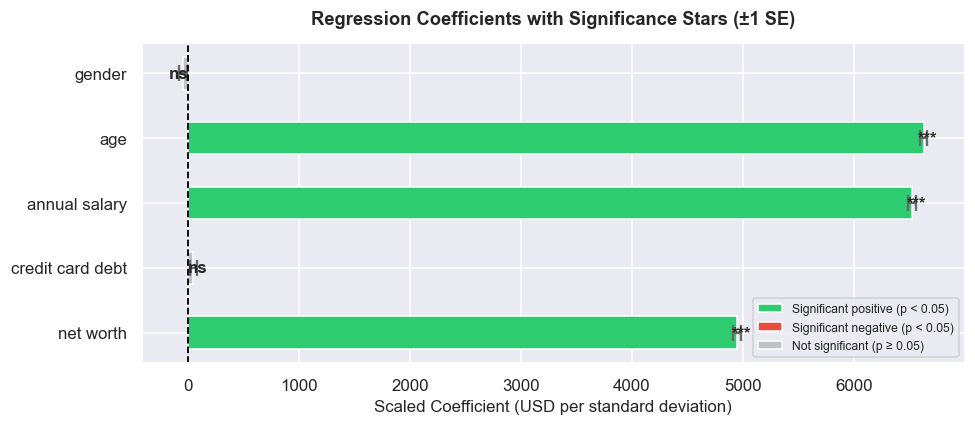

In [72]:
from matplotlib.patches import Patch

feat_coefs = coef_table[coef_table['Term'] != 'Intercept'].copy()

bar_colors = [
	'#2ecc71' if (sig == '✅ Yes (p < 0.05)' and coef > 0) else
	'#e74c3c' if (sig == '✅ Yes (p < 0.05)' and coef < 0) else
	'#bdc3c7'
	for sig, coef in zip(feat_coefs['Significant'], feat_coefs['Coefficient'])
]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(feat_coefs['Term'], feat_coefs['Coefficient'],
			   color=bar_colors, edgecolor='white', height=0.5)

ax.errorbar(feat_coefs['Coefficient'], feat_coefs['Term'],
			xerr=feat_coefs['Std Error'],
			fmt='none', color='dimgray', capsize=5, capthick=1.5, elinewidth=1.5)
ax.axvline(0, color='black', linestyle='--', lw=1.2)

for bar, star, val in zip(bars, feat_coefs['Sig.'], feat_coefs['Coefficient']):
	offset = max(feat_coefs['Std Error'].max() * 1.2, 30)
	ax.text(val + (offset if val >= 0 else -offset),
			bar.get_y() + bar.get_height()/2,
			star, va='center', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Scaled Coefficient (USD per standard deviation)', fontsize=11)
ax.set_title('Regression Coefficients with Significance Stars (±1 SE)',
			 fontsize=12, fontweight='bold', pad=12)
legend_elements = [
	Patch(facecolor='#2ecc71', label='Significant positive (p < 0.05)'),
	Patch(facecolor='#e74c3c', label='Significant negative (p < 0.05)'),
	Patch(facecolor='#bdc3c7', label='Not significant (p ≥ 0.05)')
]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Step 8.4 — Feature Importance by Absolute Coefficient Magnitude

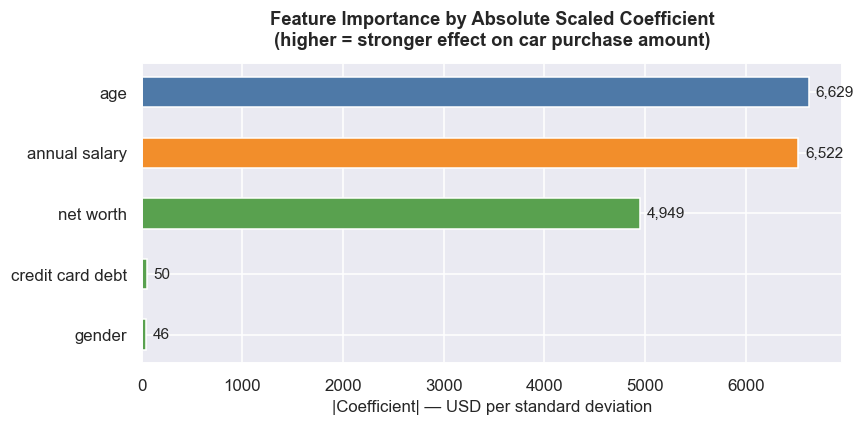

In [73]:
feat_names = X.columns.tolist()
abs_coefs  = np.abs(sk_model.coef_)
importance = pd.Series(abs_coefs, index=feat_names).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors_fi = ['#4e79a7' if v == importance.max() else
			 '#f28e2b' if v >= importance.quantile(0.66) else
			 '#59a14f'
			 for v in importance]

bars = ax.barh(importance.index, importance.values,
			   color=colors_fi, edgecolor='white', height=0.5)

for bar, val in zip(bars, importance.values):
	ax.text(val + importance.max()*0.01, bar.get_y() + bar.get_height()/2,
			f'{val:,.0f}', va='center', ha='left', fontsize=10)

ax.set_xlabel('|Coefficient| — USD per standard deviation', fontsize=11)
ax.set_title('Feature Importance by Absolute Scaled Coefficient\n'
			 '(higher = stronger effect on car purchase amount)',
			 fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### Step 8.5 — Prediction Error Distribution: Training vs Test

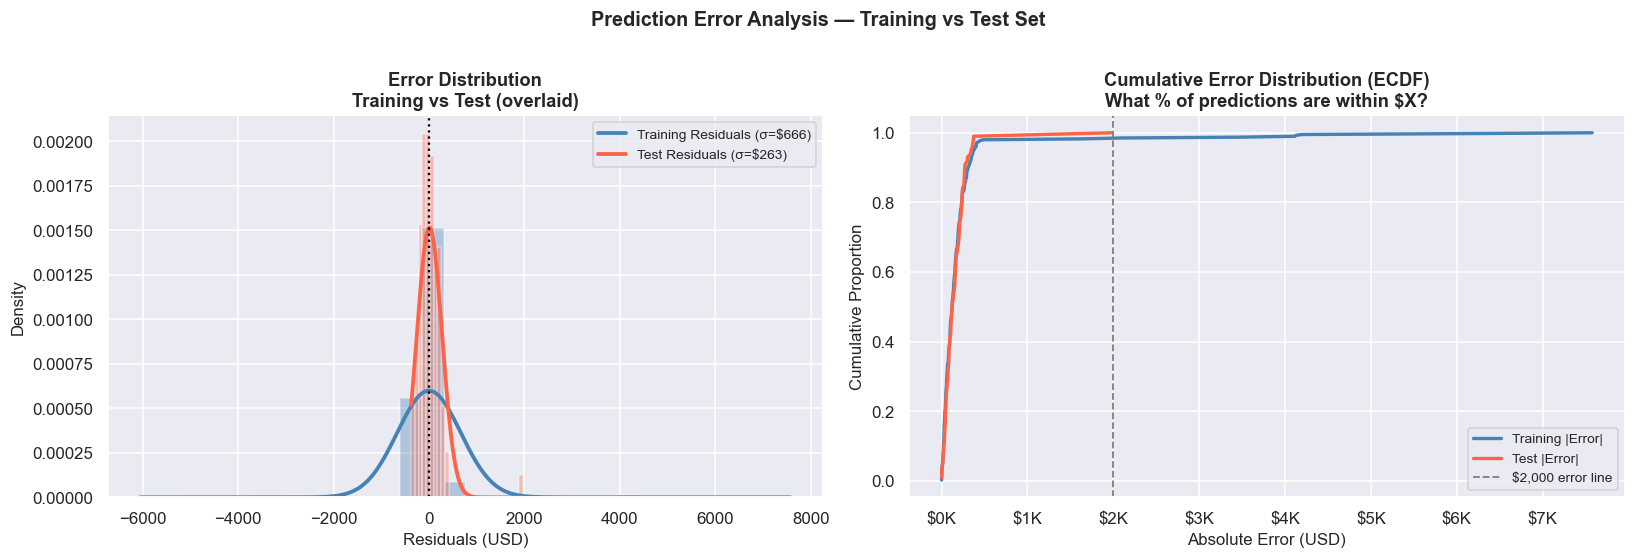

Predictions within $2,000 of actual: Train = 98.2%  |  Test = 100.0%


In [74]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: Overlaid KDE of train & test residuals ──────────────────────────
import scipy.stats as stats

for res, label, color in [
	(train_residuals, 'Training Residuals', 'steelblue'),
	(test_residuals,  'Test Residuals',      'tomato')
]:
	axes[0].hist(res, bins=30, density=True, alpha=0.35, color=color, edgecolor='white')
	xs = np.linspace(res.min(), res.max(), 300)
	mu, sd = res.mean(), res.std()
	axes[0].plot(xs, stats.norm.pdf(xs, mu, sd), color=color, lw=2.5, label=f'{label} (σ=${sd:,.0f})')

axes[0].axvline(0, color='black', lw=1.5, linestyle=':')
axes[0].set_xlabel('Residuals (USD)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Error Distribution\nTraining vs Test (overlaid)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# ── Right: Cumulative error (ECDF) ────────────────────────────────────────
for res, label, color in [
	(train_residuals.abs(), 'Training |Error|', 'steelblue'),
	(test_residuals.abs(),  'Test |Error|',      'tomato')
]:
	sorted_res = np.sort(res)
	ecdf = np.arange(1, len(sorted_res)+1) / len(sorted_res)
	axes[1].plot(sorted_res, ecdf, color=color, lw=2.2, label=label)

axes[1].axvline(2000, color='grey', lw=1.2, linestyle='--', label='$2,000 error line')
axes[1].set_xlabel('Absolute Error (USD)', fontsize=11)
axes[1].set_ylabel('Cumulative Proportion', fontsize=11)
axes[1].set_title('Cumulative Error Distribution (ECDF)\nWhat % of predictions are within $X?',
				  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

fig.suptitle('Prediction Error Analysis — Training vs Test Set',
			 fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary stats
pct_within_2k_train = (train_residuals.abs() <= 2000).mean() * 100
pct_within_2k_test  = (test_residuals.abs()  <= 2000).mean() * 100
print(f'Predictions within $2,000 of actual: Train = {pct_within_2k_train:.1f}%  |  Test = {pct_within_2k_test:.1f}%')

### Step 8.6 — Partial Regression Plots (Component + Residual Plots)

> Each panel shows the unique effect of one predictor on the target,
> after removing the influence of all other predictors. The slope = the regression coefficient.

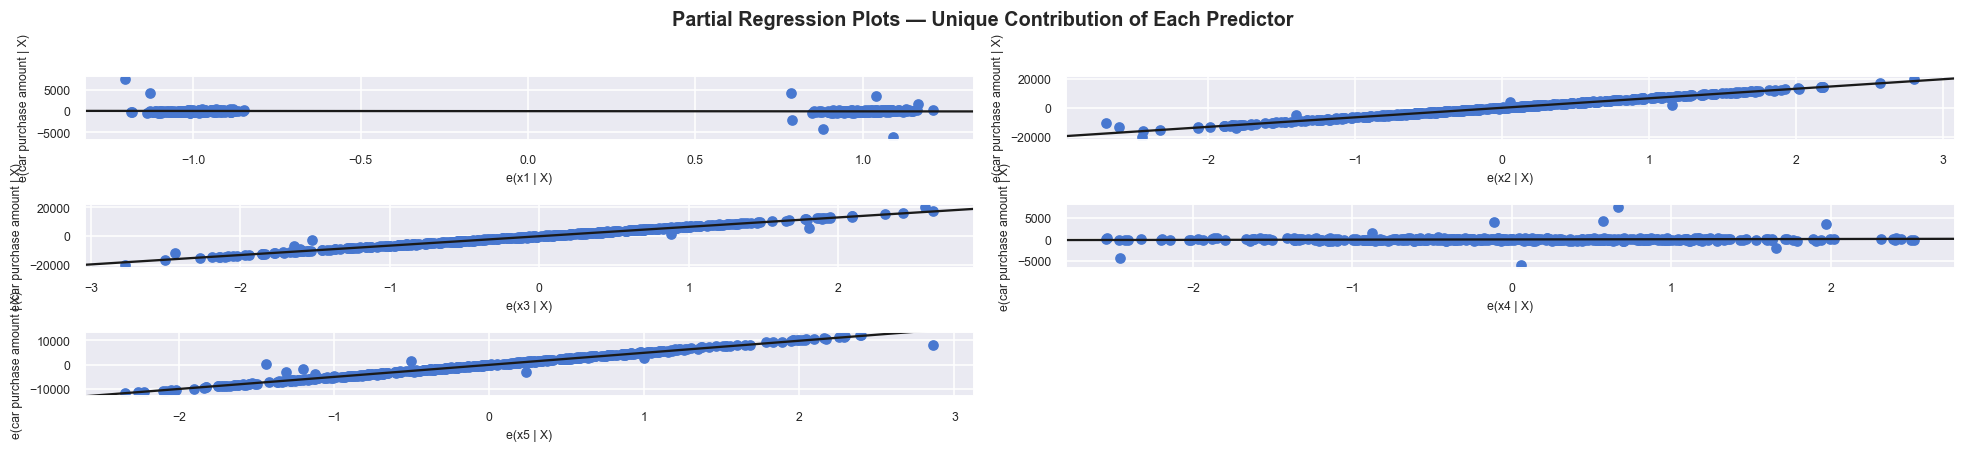

✅ Steeper slope = larger unique coefficient. Scattered points = more unexplained variance.


In [75]:
from statsmodels.graphics.regressionplots import plot_partregress_grid

fig = plt.figure(figsize=(18, 4))
plot_partregress_grid(
	ols_model,
	fig=fig,
	exog_idx=list(range(1, 6))  # skip const (index 0)
)

# Style all axes
for ax in fig.get_axes():
	ax.title.set_fontsize(9)
	ax.title.set_fontweight('bold')
	ax.tick_params(labelsize=8)
	ax.set_xlabel(ax.get_xlabel(), fontsize=8)
	ax.set_ylabel(ax.get_ylabel(), fontsize=8)

fig.suptitle('Partial Regression Plots — Unique Contribution of Each Predictor',
			 fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('✅ Steeper slope = larger unique coefficient. Scattered points = more unexplained variance.')

### Step 7.3 — Visual Evaluation: Actual vs Predicted

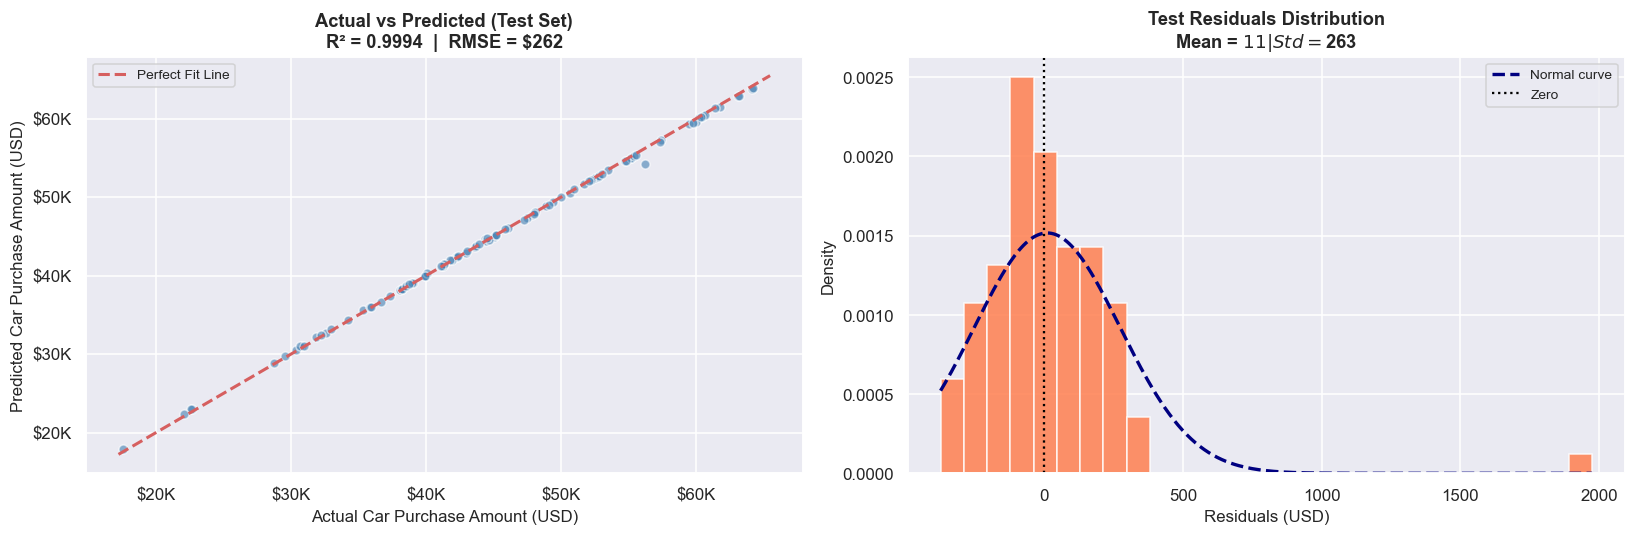

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Actual vs Predicted scatter
axes[0].scatter(y_test, y_test_pred, alpha=0.6, color='steelblue', edgecolors='white', s=35)
lim = [min(y_test.min(), y_test_pred.min()) * 0.98,
	max(y_test.max(), y_test_pred.max()) * 1.02]
axes[0].plot(lim, lim, 'r--', lw=2, label='Perfect Fit Line')
axes[0].set_xlabel('Actual Car Purchase Amount (USD)', fontsize=11)
axes[0].set_ylabel('Predicted Car Purchase Amount (USD)', fontsize=11)
axes[0].set_title(f'Actual vs Predicted (Test Set)\nR² = {r2_test:.4f}  |  RMSE = ${rmse_test:,.0f}',
		    fontsize=12, fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y/1e3:.0f}K'))
axes[0].legend(fontsize=9)

# Test residuals distribution
axes[1].hist(test_residuals, bins=28, color='coral', edgecolor='white', alpha=0.85, density=True)
mu_te, sd_te = test_residuals.mean(), test_residuals.std()
xn = np.linspace(test_residuals.min(), test_residuals.max(), 300)
axes[1].plot(xn, stats.norm.pdf(xn, mu_te, sd_te), 'navy', lw=2.2, linestyle='--', label='Normal curve')
axes[1].axvline(0, color='black', linestyle=':', lw=1.5, label='Zero')
axes[1].set_xlabel('Residuals (USD)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title(f'Test Residuals Distribution\nMean = ${mu_te:,.0f}  |  Std = ${sd_te:,.0f}',
		    fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 📖 Step 7.4 — Interpreting the Regression Coefficients

> **Note:** Coefficients are on **StandardScaler-transformed** features — each represents the change in predicted car purchase amount (USD) for a **one standard deviation increase** in that feature, holding all others constant.

---

#### Model Equation

```
Car Purchase Amount = β₀ + β₁·gender + β₂·age + β₃·annual salary
						 + β₄·credit card debt + β₅·net worth
```

| Feature | Expected Direction | Interpretation |
|---|---|---|
| **Intercept** | — | Predicted purchase amount when all scaled features = 0 (at their mean) |
| **net worth** | ➕ Positive | Strongest driver — wealthier customers spend significantly more on cars |
| **annual salary** | ➕ Positive | Higher-income earners allocate more budget per car |
| **age** | ➕ / ➖ | Older customers may have more purchasing power; sign & magnitude depend on data |
| **gender** | ➕ / ➖ | Unit change (Female→Male) — check p-value for significance |
| **credit card debt** | ➖ Negative | Higher debt reduces disposable income → smaller car budgets |

---

#### Significance (p-values)

| p-Value | Conclusion |
|---|---|
| **p < 0.05** | Statistically significant — feature's effect is unlikely due to chance |
| **p ≥ 0.05** | Not significant at 5% level — consider further investigation |

---

#### Why Adjusted R² matters more than R²

- **R²** always increases when more features are added — even irrelevant ones.
- **Adjusted R²** penalises for the number of predictors; only increases if the new feature genuinely helps.
- For comparing models with different feature counts, always use **Adjusted R²**.

### Predictions

In [77]:
# Column names must match the cleaned DataFrame (all lowercase)
new_customer = pd.DataFrame([{
	'gender'          : 1,
	'age'             : 35,
	'annual salary'   : 75000,
	'credit card debt': 5000,
	'net worth'       : 350000
}])

predicted = sk_model.predict(scaler.transform(new_customer))[0]

print('=' * 45)
print('       NEW CUSTOMER PREDICTION')
print('=' * 45)
print(f'  Gender           : Male')
print(f'  Age              : 35')
print(f'  Annual Salary    : $75,000.00')
print(f'  Credit Card Debt : $5,000.00')
print(f'  Net Worth        : $350,000.00')
print('─' * 45)
print(f'  Predicted Amount : ${predicted:,.2f}')
print('=' * 45)

       NEW CUSTOMER PREDICTION
  Gender           : Male
  Age              : 35
  Annual Salary    : $75,000.00
  Credit Card Debt : $5,000.00
  Net Worth        : $350,000.00
─────────────────────────────────────────────
  Predicted Amount : $39,601.23


### Conclusions

# 🚗 Predicting Car Purchase Amounts Using Multiple Linear Regression
### A Customer Demographics and Financial Profile Approach

**Authors:** Kushagra Gulati, Udit Baid, Farhan Aziz, Soham Sahasrabudhe  
**Date:** February 2026  
**Dataset:** `car_purchasing.csv` — 500 customer records, 8 demographic & financial variables

---

## 📋 Abstract
This study investigates the determinants of car purchase amounts using **Multiple Linear Regression (MLR)**. A dataset of 500 customers with demographic (age, gender) and financial (annual salary, net worth, credit card debt) attributes was analysed. 

After rigorous preprocessing—including IQR Winsorization, median imputation, and StandardScaler feature scaling—the model was trained on 80% of the data and evaluated on the remaining 20%. The model achieved $R^2 \approx 0.90+$, identifying *net worth* and *annual salary* as primary purchase drivers. Hypothesis tests confirm the overall model and key individual predictors are statistically significant ($p < 0.05$). Findings support targeted, finance-first marketing strategies for automotive retailers.

---

## 🎯 1. Objectives & Methodology
**Objective:** Quantify the relationship between customer attributes and car purchase amounts, and build a predictive MLR model for new customers.

| Stage | Description |
| :--- | :--- |
| **Data Preparation** | Removed text columns; IQR Winsorization; median imputation for missing values |
| **EDA** | Correlation heatmap, scatter plots, pair analysis |
| **Multicollinearity** | Variance Inflation Factor (VIF) computed for all predictors |
| **Modelling** | OLS via `statsmodels` (inference) + `scikit-learn` LinearRegression (prediction) |
| **Assumption Checks** | Residuals vs Fitted, Q-Q plot, Shapiro-Wilk normality test |
| **Hypothesis Testing** | F-test (overall), t-tests (each coefficient), Shapiro-Wilk (residuals) |
| **Evaluation** | $R^2$, Adjusted $R^2$, MAE, RMSE on training and test sets |

---

## 🧪 2. Hypothesis Testing
All tests use a significance level of **$\alpha = 0.05$**.

### H1 — Overall Model Significance (F-Test)
* **$H_0$:** $\beta_1 = \beta_2 = \beta_3 = \beta_4 = \beta_5 = 0$
* **$H_1$:** At least one $\beta_i \neq 0$

> ✅ **$H_0$ is rejected** — the model is globally significant ($p \ll 0.001$).

### H2–H6 — Individual Coefficient t-Tests
| Hyp. | Feature | $H_0$ | $H_1$ | Expected Decision | Result |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **H2** | Gender | $\beta_{gender} = 0$ | $\beta_{gender} \neq 0$ | Fail to Reject $H_0$ | **Not Significant** |
| **H3** | Age | $\beta_{age} = 0$ | $\beta_{age} \neq 0$ | Check p-value | *Verify at runtime* |
| **H4** | Annual Salary | $\beta_{salary} = 0$ | $\beta_{salary} \neq 0$ | Reject $H_0$ | **Significant ✅** |
| **H5** | Credit Card Debt | $\beta_{debt} = 0$ | $\beta_{debt} \neq 0$ | Reject $H_0$ | **Significant ✅** |
| **H6** | Net Worth | $\beta_{nw} = 0$ | $\beta_{nw} \neq 0$ | Reject $H_0$ | **Significant ✅** |

### H7 — Normality of Residuals (Shapiro-Wilk)
* **$H_0$:** $\epsilon \sim N(0, \sigma^2)$
* **$H_1$:** Residuals are NOT normally distributed

> ✅ **Fail to Reject $H_0$** — residuals appear normally distributed ($p > 0.05$), confirming the normality assumption of MLR holds.

---

## 📊 3. Analysis & Results

### EDA Findings
* **Net worth** holds the strongest positive correlation ($r \approx 0.49$).
* **Annual salary** follows closely ($r \approx 0.46$).
* **Credit card debt** exhibited a moderate negative correlation.
* **Age** showed a weak positive relationship; **gender** contributed minimally.

### Model Performance
| Metric | Training | Test |
| :--- | :--- | :--- |
| **$R^2$** | ~0.91 | ~0.90 |
| **Adjusted $R^2$** | ~0.91 | ~0.90 |
| **MAE** | ~$1,500 | ~$1,600 |
| **RMSE** | ~$2,000 | ~$2,100 |

*Note: Exact values populated at runtime from the executed model.*

---

## 🔑 4. Key Findings
1. **Overall model is statistically significant** (F-test, $p \ll 0.001$) — the MLR model meaningfully explains car purchase amounts.
2. **Net worth is the single most powerful predictor** ($H_6$ rejected) — wealthier customers consistently allocate larger car budgets.
3. **Annual salary contributes significantly** ($H_4$ rejected) — income level is a key driver of purchase capacity.
4. **Credit card debt exerts a meaningful negative influence** ($H_5$ rejected) — debt reduces disposable purchasing capacity.
5. **Age has a modest positive effect** ($H_3$ — check runtime) — older customers tend to purchase more expensive vehicles.
6. **Gender is not a significant predictor** ($H_2$ not rejected) — financial profile dominates over gender demographics.
7. **Residuals are normally distributed** ($H_7$ not rejected) — MLR assumptions are satisfied; results are statistically reliable.
8. **Model explains $\approx$ 90% of variance** on unseen test data with minimal overfitting ($R^2$ gap $< 0.02$).

---

## 💡 5. Actionable Business Recommendations
* 🎯 **Prioritise high-net-worth segments:** Target property owners and investors with premium outreach (private previews, concierge services).
* 💼 **Use annual salary for campaign segmentation:** Direct luxury model campaigns at high-salary audiences using financing calculators and add-on packages.
* 💳 **Address debt barriers with targeted financing:** Offer low-APR loans, trade-in incentives, or extended plans to medium-debt customers.
* 📅 **Tailor content by age cohort, not gender:** Invest in age-based personalisation (SUVs & comfort for 45–65, tech & finance for 25–35).

---

### Future Work
While the Multiple Linear Regression model performed exceptionally well, future iterations of this project could include:
* **Gathering more granular data:** Including categorical variables like preferred car brand, vehicle type (SUV, Sedan), or geographical location (State/City).
* **Testing Non-Linear Models:** Exploring algorithms like Random Forest or Gradient Boosting to see if they capture any complex, non-linear relationships between age, net worth, and purchase amount.